In [ ]:
# ========= CONFIG (fill locally; do NOT commit secrets) =========
# Tip: use environment variables or a local `.env` file.
# Example:
#   import os
#   OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
#   HF_TOKEN = os.getenv("HF_TOKEN", "")
# ===============================================================



# Enabling the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

[Reference](https://colab.research.google.com/notebooks/gpu.ipynb)

# ++++++++++++++USE HDBSCAN instead of DBSCAN

# **Installing BERTopic**

We start by installing BERTopic from PyPi:

In [1]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.7 MB/s eta 0:00:00


# Access the filtered, aka complete dataset


Navigate the drive folder

In [2]:
import pandas as pd
from google.colab import drive
import os

# Parameters for dataset
sector = 'camera'
# sector = 'robotics'
# sector = 'semiconductor chips'
# sector = 'mobile_phone'
dataset = 'complete'
# dataset = 'topic_unfiltered'

# Navigate the folder location
drive.mount("/content/drive")
folder_path = f"/content/drive/MyDrive/TechShiftProject/{sector}/{dataset}_data/"

Mounted at /content/drive


Get the dataframe for all patents

In [3]:
df = pd.read_csv(f"{folder_path}df_id_year_document.csv")
print(len(df))

1457933


In [ ]:
print(2308445+224989+364422)    # unfiltered number
print(1457933+172099+338008)    # filtered number

2897856
1968040


In [4]:
# Load the csv file
df = pd.read_csv(f"{folder_path}df_id_year_document.csv")
# Convert only float entries in 'document' column to strings
df['document'] = df['document'].apply(lambda x: str(x) if isinstance(x, float) else x)

print(len(df))

# Count the number of rows per unique year
year_counts = df['year'].value_counts().sort_index()

# Print the results to determine the start year and end yaer
for year, count in year_counts.items():
    print(f"Year: {year}, Count: {count}")

1457933
Year: 1900.0, Count: 6
Year: 1901.0, Count: 14
Year: 1902.0, Count: 12
Year: 1903.0, Count: 15
Year: 1904.0, Count: 21
Year: 1905.0, Count: 14
Year: 1906.0, Count: 8
Year: 1907.0, Count: 8
Year: 1908.0, Count: 19
Year: 1909.0, Count: 23
Year: 1910.0, Count: 8
Year: 1911.0, Count: 9
Year: 1912.0, Count: 12
Year: 1913.0, Count: 16
Year: 1914.0, Count: 15
Year: 1915.0, Count: 20
Year: 1916.0, Count: 26
Year: 1917.0, Count: 46
Year: 1918.0, Count: 53
Year: 1919.0, Count: 19
Year: 1920.0, Count: 19
Year: 1921.0, Count: 36
Year: 1922.0, Count: 35
Year: 1923.0, Count: 55
Year: 1924.0, Count: 40
Year: 1925.0, Count: 44
Year: 1926.0, Count: 60
Year: 1927.0, Count: 52
Year: 1928.0, Count: 72
Year: 1929.0, Count: 80
Year: 1930.0, Count: 142
Year: 1931.0, Count: 248
Year: 1932.0, Count: 271
Year: 1933.0, Count: 274
Year: 1934.0, Count: 282
Year: 1935.0, Count: 299
Year: 1936.0, Count: 321
Year: 1937.0, Count: 320
Year: 1938.0, Count: 496
Year: 1939.0, Count: 584
Year: 1940.0, Count: 449
Ye

Prepare the data so they are correctly structured for the data analysis

In [5]:
# Choose the start year and end year
# Camera
start_year = 1930
end_year = 2023    # the year to end

# # Robotics
# start_year = 1975
# end_year = 2024    # the year to end

# # Semi
# start_year = 1965
# end_year = 2024

# # Mobile Phone
# start_year = 1962
# end_year = 2024



# Choose the size of minimum cluster
# Camera
min_cluster_size = 1000    # The larger the cluster size, the fewer the topics
# min_cluster_size = 500
# # Robotics and Semi
# min_cluster_size = 500
# # Mobile
# min_cluster_size = 300

year_window = 20
# year_window = 10

# Prepare folders for further analysis

embedding_path = f'{folder_path}embedding_analysis_end_{end_year}/'
dynamic_embedding_path = f'{folder_path}dynamic_embedding_{year_window}_end_{end_year}/'
dynamic_topic_path = f'{folder_path}dynamic_topic_{min_cluster_size}_{year_window}_end_{end_year}/'
predictivity_path = f'{folder_path}predictivity_{min_cluster_size}_{year_window}_end_{end_year}/'

if not os.path.exists(embedding_path):
    os.makedirs(embedding_path)
if not os.path.exists(dynamic_embedding_path):
    os.makedirs(dynamic_embedding_path)
if not os.path.exists(dynamic_topic_path):
    os.makedirs(dynamic_topic_path)
if not os.path.exists(predictivity_path):
    os.makedirs(predictivity_path)

Filter out the years outside the overall range

In [6]:
# Filter out all rows earlier than start_year
df = df[(df["year"] >= start_year) & (df["year"] <= end_year)]
df.reset_index(drop=True, inplace=True)

**Looping**

Create the loop to get embeddings and topic for a moving year windlow

In [ ]:
# Import all library needed for this block
from sentence_transformers import SentenceTransformer
import pickle
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# Define the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Get the stop word list
stop_words = text.ENGLISH_STOP_WORDS.union(['first', 'second', 'third', 'sb', 'thereof', 'include',
                                            'method', 'including', 'includes', 'solve', 'solved', 'solution',
                                            'jpo', 'inpit', 'ncip', 'copyright', 'problem', 'invention',
                                            'innovation', 'provide', 'provides', 'provided', 'following',
                                            'result', 'describe', 'wherein', 'left', 'right', 'purpose', 'constitution',
                                            'january', 'jan', 'february', 'feb', 'march', 'mar', 'april', 'may', 'june',
                                            'july', 'august', 'aug', 'september', 'sep', 'october', 'oct', 'november', 'nov',
                                            'december', 'dec', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',
                                            'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',
                                            'eleven', 'twelve', 'thirteen', 'fourteen', 'fifteen', 'sixteen', 'seventeen',
                                            'eighteen', 'nineteen', 'twenty', 'thirty', 'forty', 'fifty', 'sixty',
                                            'seventy', 'eighty', 'ninety', 'hundred'])
stop_words = list(stop_words)

# Start looping for embedding and topic modelling for each year window
for start in range(start_year, end_year - year_window + 2):

    ## Step 1: Prepare the yearly moving windows for the analysis
    print(f"\nProcessing window: {start}-{start + year_window - 1}")
    end = start + year_window - 1
    window_folder = os.path.join(dynamic_topic_path, f"{start}_{end}/")
    window_folder_embedding = os.path.join(dynamic_embedding_path, f"{start}_{end}/")
    if not os.path.exists(window_folder):
        os.makedirs(window_folder)
    if not os.path.exists(window_folder_embedding):
        os.makedirs(window_folder_embedding)

    # Get the dataframe within the year window
    df_window = df[(df["year"] >= start) & (df["year"] <= end)]
    df_window.reset_index(drop=True, inplace=True)

    # Extract contents to train on and corresponding ids
    contents = df_window["document"]
    ids = df_window["id"]

    print(f"Number of documents: {len(contents)}")
    print("Example content snippet:")
    print(contents.iloc[0][:300] + "...\n")

    ## Step 2: Get the embeddings
    print("Generating embeddings...")
    embeddings = embedding_model.encode(contents, show_progress_bar=True)
    with open(f"{window_folder_embedding}embeddings.pkl", "wb") as f:
        pickle.dump(embeddings, f)
    print("Embeddings saved.")

    # ## Step 2 (alternative): Load the embeddings from already processed embeddings
    # print("Loading embeddings")
    # with open(f"{window_folder_embedding}embeddings.pkl", "rb") as f:
    #     embeddings = pickle.load(f)
    # print("Embedding loaded")


    ## Step 3: Prepare for training
    print("Preparing vectorizer and representation models...")

    # Parameter UMAP and HDSCAN
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
    # Size needs to be sufficiently small compared to the contents length)
    if min_cluster_size < len(contents)/15:
        hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=True, core_dist_n_jobs=1)
    else:
        hdbscan_model = HDBSCAN(min_cluster_size=int(len(contents)/15), metric='euclidean', cluster_selection_method='eom', prediction_data=True, core_dist_n_jobs=1)
    vectorizer_model = CountVectorizer(stop_words=stop_words, min_df=2, ngram_range=(1, 2))

    keybert_model = KeyBERTInspired()
    pos_model = PartOfSpeech("en_core_web_sm")
    mmr_model = MaximalMarginalRelevance(diversity=0.3)

    representation_model = {
        "KeyBERT": keybert_model,
        "MMR": mmr_model,
        "POS": pos_model
    }

    ## Step 4: Training
    print("Training BERTopic model...")
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        top_n_words=10,
        verbose=True,
        calculate_probabilities=True,
        low_memory=True
    )

    topics, probs = topic_model.fit_transform(contents, embeddings)
    print("Model training completed.")

    print("Saving model and outputs...")
    topic_model.save(window_folder, serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

    df_window["topic"] = topics
    df_window["probs"] = probs.tolist()

    df_id_year_topic = df_window.drop(columns=['document', 'probs'])
    df_id_year_topic.to_csv(f'{window_folder}df_id_year_topic.csv', index=False)

    df_topic_info = topic_model.get_topic_info()
    print(f'Number of topics: {len(df_topic_info)}')
    df_topic_info.to_csv(f'{window_folder}topic_info.csv', index=False)

    df_window = df_window.drop(columns=['document'])
    df_window.to_csv(f'{window_folder}topic_probs_matrix.csv', index=False)



    print(f"Finished processing window: {start}-{end}")


Processing window: 1931-2010
Number of documents: 1051626
Example content snippet:
Keyboard switch  keyboard switch abstract keyboard switch use membrane switch array provide tactile feeling optionally click sound comprises housing positioned membrane switch array plunger reciprocally mounted within housing projects outwardly housing plunger cam portion actuating arm pivoted housi...

Generating embeddings...


Batches:   0%|          | 0/32864 [00:00<?, ?it/s]

Embeddings saved.
Finished processing window: 1931-2010

Processing window: 1932-2011
Number of documents: 1088324
Example content snippet:
Keyboard switch  keyboard switch abstract keyboard switch use membrane switch array provide tactile feeling optionally click sound comprises housing positioned membrane switch array plunger reciprocally mounted within housing projects outwardly housing plunger cam portion actuating arm pivoted housi...

Generating embeddings...


Batches:   0%|          | 0/34011 [00:00<?, ?it/s]

Embeddings saved.
Finished processing window: 1932-2011

Processing window: 1933-2012
Number of documents: 1124758
Example content snippet:
Keyboard switch  keyboard switch abstract keyboard switch use membrane switch array provide tactile feeling optionally click sound comprises housing positioned membrane switch array plunger reciprocally mounted within housing projects outwardly housing plunger cam portion actuating arm pivoted housi...

Generating embeddings...


...

Embeddings saved.
Finished processing window: 1942-2021

Processing window: 1943-2022
Number of documents: 1441831
Example content snippet:
Keyboard switch  keyboard switch abstract keyboard switch use membrane switch array provide tactile feeling optionally click sound comprises housing positioned membrane switch array plunger reciprocally mounted within housing projects outwardly housing plunger cam portion actuating arm pivoted housi...

Generating embeddings...


Batches:   0%|          | 0/45058 [00:00<?, ?it/s]

Embeddings saved.
Finished processing window: 1943-2022

Processing window: 1944-2023
Number of documents: 1452235
Example content snippet:
Keyboard switch  keyboard switch abstract keyboard switch use membrane switch array provide tactile feeling optionally click sound comprises housing positioned membrane switch array plunger reciprocally mounted within housing projects outwardly housing plunger cam portion actuating arm pivoted housi...

Generating embeddings...


Batches:   0%|          | 0/45383 [00:00<?, ?it/s]

Embeddings saved.
Finished processing window: 1944-2023


# Get the rate of meta topic change and angle difference with given truncated year

Get the topics of truncated years as a dataframe

In [24]:
# truncated_year = 2023
# truncated_year = 2020
# truncated_year = 2010
truncated_year = 2000
# truncated_year = 1990
# truncated_year = 1980
# truncated_year = 1975
truncated_path = os.path.join(predictivity_path, f"end_{truncated_year}/")
if not os.path.exists(truncated_path):
    os.makedirs(truncated_path)

In [ ]:
import ast


# Initialize an empty DataFrame to store topic info across all year windows
df_clustered_topics_truncated_year = pd.DataFrame([])

# Loop through time windows
for start in range(start_year, truncated_year - year_window + 2):
    end = start + year_window - 1
    print(f"\n=== Processing window: {start}-{end} ===")

    # Define the path to the current window's topic info file
    window_folder = os.path.join(dynamic_topic_path, f"{start}_{end}/")

    # Load topic information CSV
    df_topic_info = pd.read_csv(f"{window_folder}topic_info.csv")

    # Remove the first row of outliers
    df_topic_info = df_topic_info.iloc[1:]

    # Convert string representations of lists into actual Python lists
    for col in ['Representation', 'KeyBERT', 'MMR', 'POS']:
        df_topic_info[col] = df_topic_info[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else []
        )

    # Combine keywords from multiple sources into a unique list
    df_topic_info['keywords'] = df_topic_info.apply(
        lambda row: list(set(row['Representation'] + row['KeyBERT'] + row['MMR'] + row['POS'])),
        axis=1
    )

    # Add a column indicating the current year window
    df_topic_info['year_window'] = f"{start}-{end}"

    # Rename 'Topic' to lowercase 'topic' for consistency
    df_topic_info.rename(columns={'Topic': 'topic'}, inplace=True)

    # Select only relevant columns
    df_topic_info = df_topic_info[['topic', 'keywords', 'year_window']]

    # Concatenate the current window's topics into the master DataFrame
    df_clustered_topics_truncated_year = pd.concat([df_clustered_topics_truncated_year, df_topic_info])
    print((f"=== Window contatenated: {start}-{end} ==="))

# Save the aggregated topic info across all year windows to a CSV
df_clustered_topics_truncated_year.to_csv(os.path.join(truncated_path, "topic_info_truncated_year_window.csv"), index=False)


=== Processing window: 1930-1949 ===
=== Window contatenated: 1930-1949 ===

=== Processing window: 1931-1950 ===
=== Window contatenated: 1931-1950 ===

=== Processing window: 1932-1951 ===
=== Window contatenated: 1932-1951 ===

=== Processing window: 1933-1952 ===
=== Window contatenated: 1933-1952 ===

=== Processing window: 1934-1953 ===
=== Window contatenated: 1934-1953 ===

=== Processing window: 1935-1954 ===
=== Window contatenated: 1935-1954 ===

=== Processing window: 1936-1955 ===
=== Window contatenated: 1936-1955 ===

=== Processing window: 1937-1956 ===
=== Window contatenated: 1937-1956 ===

=== Processing window: 1938-1957 ===
=== Window contatenated: 1938-1957 ===

=== Processing window: 1939-1958 ===
=== Window contatenated: 1939-1958 ===

=== Processing window: 1940-1959 ===
=== Window contatenated: 1940-1959 ===

=== Processing window: 1941-1960 ===
=== Window contatenated: 1941-1960 ===

=== Processing window: 1942-1961 ===
=== Window contatenated: 1942-1961 ===

Cluster topics of all years using **HDBSCAN**

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
from ast import literal_eval
from collections import Counter
from sklearn.metrics import pairwise_distances, silhouette_score
import hdbscan  # New import for HDBSCAN

# Load the data
df_clustered_topics_truncated_year = pd.read_csv(os.path.join(truncated_path, "topic_info_truncated_year_window.csv"))

# Step 1: Convert 'keywords' column from string to list
df_clustered_topics_truncated_year['keywords'] = df_clustered_topics_truncated_year['keywords'].apply(lambda x: literal_eval(x))

# Step 2: Compute Jaccard distances and cluster with HDBSCAN
all_keywords = ""  # TODO: fill in (do not commit)
vocabulary = list(set(all_keywords))
binary_matrix = np.array([
    [1 if keyword in row['keywords'] else 0 for keyword in vocabulary]
    for _, row in df_clustered_topics_truncated_year.iterrows()
])
jaccard_distances = pairwise_distances(binary_matrix, metric='jaccard')

# HDBSCAN parameters
# Camera
# min_cluster_size = 3
min_cluster_size = 5    # larger min_cluster_size, less clusters
# min_cluster_size = 10
min_samples = 1         # larger min_samples, the criterion to be a cluster is stricter, hence more points considered to be noise, and there are less topic
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='precomputed')
cluster_labels = clusterer.fit_predict(jaccard_distances)
df_clustered_topics_truncated_year['cluster_id'] = cluster_labels

# Step 3: Add number of topics in each cluster
cluster_sizes = df_clustered_topics_truncated_year.groupby('cluster_id').size().reset_index(name='num_topics_in_cluster')
df_clustered_topics_truncated_year = df_clustered_topics_truncated_year.merge(cluster_sizes, on='cluster_id', how='left')

# Step 4: Generate representative keywords and cluster names
cluster_reps = {}
unique_clusters = df_clustered_topics_truncated_year['cluster_id'].unique()
for cid in unique_clusters:
    subset = df_clustered_topics_truncated_year[df_clustered_topics_truncated_year['cluster_id'] == cid]
    all_kws = []
    for _, r in subset.iterrows():
        kw_list = literal_eval(r['keywords']) if isinstance(r['keywords'], str) else r['keywords']
        all_kws.extend(kw_list)
    freq = Counter(all_kws)
    top30 = [w for w, _ in freq.most_common(30)]
    top5 = [w for w, _ in freq.most_common(5)]
    cluster_name = "_".join(top5)
    cluster_reps[cid] = {
        'representative_keywords': top30,
        'cluster_name': cluster_name
    }

df_clustered_topics_truncated_year['representative_keywords'] = df_clustered_topics_truncated_year['cluster_id'].apply(
    lambda x: cluster_reps[x]['representative_keywords']
)
df_clustered_topics_truncated_year['cluster_name'] = df_clustered_topics_truncated_year['cluster_id'].apply(
    lambda x: cluster_reps[x]['cluster_name']
)

# Print number of clusters
n_cluster = len(df_clustered_topics_truncated_year['cluster_id'].unique())
print(f"Number of clusters: {n_cluster}")

# Calculate and print the number of noise points
num_noise_points = (df_clustered_topics_truncated_year['cluster_id'] == -1).sum()
total_points = len(df_clustered_topics_truncated_year)
print(f"Number of noise points: {num_noise_points} out of {total_points} total points")

# Step 5: Compute silhouette score and average intra-cluster Jaccard distance
silhouette_avg = silhouette_score(jaccard_distances, cluster_labels, metric='precomputed')
print(f"Silhouette Score: {silhouette_avg}")
intra_cluster_distances = []
for cluster in set(cluster_labels):
    if cluster != -1:
        cluster_indices = np.where(cluster_labels == cluster)[0]
        cluster_distances = jaccard_distances[cluster_indices][:, cluster_indices]
        intra_cluster_distances.append(np.mean(cluster_distances))
avg_intra_cluster_distance = (
    np.mean(intra_cluster_distances) if intra_cluster_distances else 0
)
print(f"Average Intra-Cluster Jaccard Distance: {avg_intra_cluster_distance}")

Number of clusters: 13
Number of noise points: 8 out of 124 total points
Silhouette Score: 0.3409331329985571
Average Intra-Cluster Jaccard Distance: 0.39508177394840477


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [ ]:
# Step 6: Save the final result
cluster_path = os.path.join(truncated_path, f"cluster_number_{n_cluster}")
os.makedirs(cluster_path, exist_ok=True)
output_file = os.path.join(cluster_path, "clustered_topics_truncated_year.csv")
df_clustered_topics_truncated_year.to_csv(output_file, index=False)
print(f"Result dataframe saved to: {output_file}")

Result dataframe saved to: /content/drive/MyDrive/TechShiftProject/camera/complete_data/predictivity_500_10_end_2023/end_1980/cluster_number_13/clustered_topics_truncated_year.csv


Get ave_vector and sum_vector

In [ ]:
import pandas as pd
import numpy as np
import ast

# Container to hold all result DataFrames
all_results = []

# Main loop for processing year windows
for start in range(start_year, end_year - year_window + 2):
    end = start + year_window - 1
    print(f"\n=== Processing window: {start}-{end} ===")

    window_folder = os.path.join(dynamic_topic_path, f"{start}_{end}/")
    window_folder_embedding = os.path.join(dynamic_embedding_path, f"{start}_{end}/")

    # Load CSV and parse stringified vectors
    print("Loading topic_probs_matrix.csv...")
    df = pd.read_csv(f'{window_folder}topic_probs_matrix.csv')
    df['probs'] = df['probs'].apply(ast.literal_eval)
    print("CSV loaded and 'probs' column parsed.")

    # Compute average and sum vectors
    print("Computing average and sum topic vectors...")
    avg_vectors_raw = df.groupby('year')['probs'].apply(lambda x: np.mean(np.vstack(x), axis=0)).reset_index()
    sum_vectors_raw = df.groupby('year')['probs'].apply(lambda x: np.sum(np.vstack(x), axis=0)).reset_index()

    # Expand vectors into topic columns
    print("Expanding topic vectors into columns...")
    num_topics = len(avg_vectors_raw['probs'].iloc[0])
    avg_vectors = pd.concat([
        avg_vectors_raw[['year']],
        pd.DataFrame(avg_vectors_raw['probs'].tolist(), columns=[f'topic_{i}' for i in range(num_topics)])
    ], axis=1)

    sum_vectors = pd.concat([
        sum_vectors_raw[['year']],
        pd.DataFrame(sum_vectors_raw['probs'].tolist(), columns=[f'topic_{i}' for i in range(num_topics)])
    ], axis=1)

    # Save the processed vectors
    avg_vectors.to_pickle(f"{window_folder}avg_vectors.pkl")
    sum_vectors.to_pickle(f"{window_folder}sum_vectors.pkl")
    print("Saved avg_vectors.pkl and sum_vectors.pkl.")


=== Processing window: 1930-1939 ===
Loading topic_probs_matrix.csv...
CSV loaded and 'probs' column parsed.
Computing average and sum topic vectors...
Expanding topic vectors into columns...
Saved avg_vectors.pkl and sum_vectors.pkl.

=== Processing window: 1931-1940 ===
Loading topic_probs_matrix.csv...
CSV loaded and 'probs' column parsed.
Computing average and sum topic vectors...
Expanding topic vectors into columns...
Saved avg_vectors.pkl and sum_vectors.pkl.

=== Processing window: 1932-1941 ===
Loading topic_probs_matrix.csv...
CSV loaded and 'probs' column parsed.
Computing average and sum topic vectors...
Expanding topic vectors into columns...
Saved avg_vectors.pkl and sum_vectors.pkl.

=== Processing window: 1933-1942 ===
Loading topic_probs_matrix.csv...
CSV loaded and 'probs' column parsed.
Computing average and sum topic vectors...
Expanding topic vectors into columns...
Saved avg_vectors.pkl and sum_vectors.pkl.

=== Processing window: 1934-1943 ===
Loading topic_prob

KeyboardInterrupt: 

Define cluster_path

In [27]:
# n_cluster = 71    # camera HDB year_window 20 end 2023 min_cluster_size = 10
# n_cluster = 68    # camera HDB year_window 20 end 2020 min_cluster_size = 10
# n_cluster = 106    # camera HDB year_window 20 end 2020 min_cluster_size = 5
# n_cluster = 47    # camera HDB year_window 20 end 2010 min_cluster_size = 10
# n_cluster = 70    # camera HDB year_window 20 end 2010 min_cluster_size = 5
# n_cluster = 24    # camera HDB year_window 20 end 2000 min_cluster_size = 10
n_cluster = 41    # camera HDB year_window 20 end 2000 min_cluster_size = 5
# n_cluster = 10    # camera HDB year_window 20 end 1990 min_cluster_size = 5
# n_cluster = 32    # camera HDB year_window 20 end 1990 min_cluster_size = 3
# n_cluster = 5    # camera HDB year_window 20 end 1980 min_cluster_size = 5
# n_cluster = 4    # camera HDB year_window 20 end 1975 min_cluster_size = 5


# n_cluster = 89    # camera HDB year_window 10 end 2023 min_cluster_size = 10
# n_cluster = 85    # camera HDB year_window 10 end 2020 min_cluster_size = 10
# n_cluster = 56    # camera HDB year_window 10 end 2010 min_cluster_size = 10
# n_cluster = 40    # camera HDB year_window 10 end 2000 min_cluster_size = 10
# n_cluster = 12    # camera HDB year_window 10 end 1990 min_cluster_size = 10
# n_cluster = 29    # camera HDB year_window 10 end 1990 min_cluster_size = 5
# n_cluster = 13    # camera HDB year_window 10 end 1990 min_cluster_size = 5

cluster_path = os.path.join(truncated_path, f"cluster_number_{n_cluster}")

Get cluster-year distribution vectors

In [ ]:
import pickle
import pandas as pd
import os

# Get the dataframe of all clusters (meta-topics)
df_clustered_topics_truncated_year = pd.read_csv(os.path.join(cluster_path, "clustered_topics_truncated_year.csv"))
# Keep the columns needed
df_clustered_topics_truncated_year = df_clustered_topics_truncated_year[['year_window','topic','cluster_id']]

# List to store all sum_vectors DataFrames
all_sum_vectors = []

# Main loop for processing year windows
for start in range(start_year, truncated_year - year_window + 2):
    end = start + year_window - 1
    print(f"\n=== Processing window: {start}-{end} ===")

    window_folder = os.path.join(dynamic_topic_path, f"{start}_{end}/")

    # Load average topic vectors
    sum_vectors = pd.read_pickle(f"{window_folder}sum_vectors.pkl")
    print("Sum topic vectors loaded.")

    # Transpose the DataFrame and rename columns
    sum_vectors = sum_vectors.set_index('year').transpose().reset_index()
    sum_vectors.columns = ['topic'] + [str(int(year)) for year in sum_vectors.columns[1:]]

    # Remove 'topic_' prefix from topic names and convert to int
    sum_vectors['topic'] = sum_vectors['topic'].str.replace('topic_', '').astype(int)

    # Filter df_clustered_topics_truncated_year for the current year window
    current_window = f"{start}-{end}"
    cluster_data = df_clustered_topics_truncated_year[df_clustered_topics_truncated_year['year_window'] == current_window][['topic', 'cluster_id']]

    # Merge sum_vectors with cluster_data to add cluster_id
    sum_vectors = sum_vectors.merge(cluster_data, on='topic', how='left')

    # Add missing year columns from start_year to end_year
    all_years = [str(year) for year in range(start_year, truncated_year + 1)]
    current_years = [col for col in sum_vectors.columns if col not in ['topic', 'cluster_id']]
    missing_years = [year for year in all_years if year not in current_years]

    # Add missing year columns with zeros
    for year in missing_years:
        sum_vectors[year] = 0

    # Reorder columns to ensure consistent year order
    sum_vectors = sum_vectors[['topic', 'cluster_id'] + all_years]

    # Append to list
    all_sum_vectors.append(sum_vectors)

# Concatenate all sum_vectors DataFrames
concatenated_sum_vectors = pd.concat(all_sum_vectors, ignore_index=True)

# Aggregate by cluster_id, summing year columns and dropping topic
cluster_sum_vectors = concatenated_sum_vectors.drop(columns=['topic']).groupby('cluster_id').sum().reset_index()

# Save to pickle
cluster_sum_vectors.to_pickle(os.path.join(cluster_path, "cluster_sum_vector.pkl"))

# Calculate proportions for each year (normalize so each year column sums to 1)
year_columns = [col for col in cluster_sum_vectors.columns if col != 'cluster_id']
cluster_ave_vectors = cluster_sum_vectors.copy()
cluster_ave_vectors[year_columns] = cluster_ave_vectors[year_columns].div(cluster_ave_vectors[year_columns].sum())

# Save to pickle
cluster_ave_vectors.to_pickle(os.path.join(cluster_path, "cluster_ave_vector.pkl"))



=== Processing window: 1930-1939 ===
Sum topic vectors loaded.

=== Processing window: 1931-1940 ===
Sum topic vectors loaded.

=== Processing window: 1932-1941 ===
Sum topic vectors loaded.

=== Processing window: 1933-1942 ===
Sum topic vectors loaded.

=== Processing window: 1934-1943 ===
Sum topic vectors loaded.

=== Processing window: 1935-1944 ===
Sum topic vectors loaded.

=== Processing window: 1936-1945 ===
Sum topic vectors loaded.

=== Processing window: 1937-1946 ===
Sum topic vectors loaded.

=== Processing window: 1938-1947 ===
Sum topic vectors loaded.

=== Processing window: 1939-1948 ===
Sum topic vectors loaded.

=== Processing window: 1940-1949 ===
Sum topic vectors loaded.

=== Processing window: 1941-1950 ===
Sum topic vectors loaded.

=== Processing window: 1942-1951 ===
Sum topic vectors loaded.

=== Processing window: 1943-1952 ===
Sum topic vectors loaded.

=== Processing window: 1944-1953 ===
Sum topic vectors loaded.

=== Processing window: 1945-1954 ===
Su

Reorder the cluster_ave_vectors and plot the stacked trends of proportion of clusters agains year


=== Cluster Average (Proportion) Vectors (Sorted by Weighted Mean Year) ===

=== Stacked Colored Plot saved to /content/drive/MyDrive/TechShiftProject/camera/complete_data/predictivity_500_10_end_2023/end_1980/cluster_number_13/cluster_proportion_trends_stacked_colored.png ===


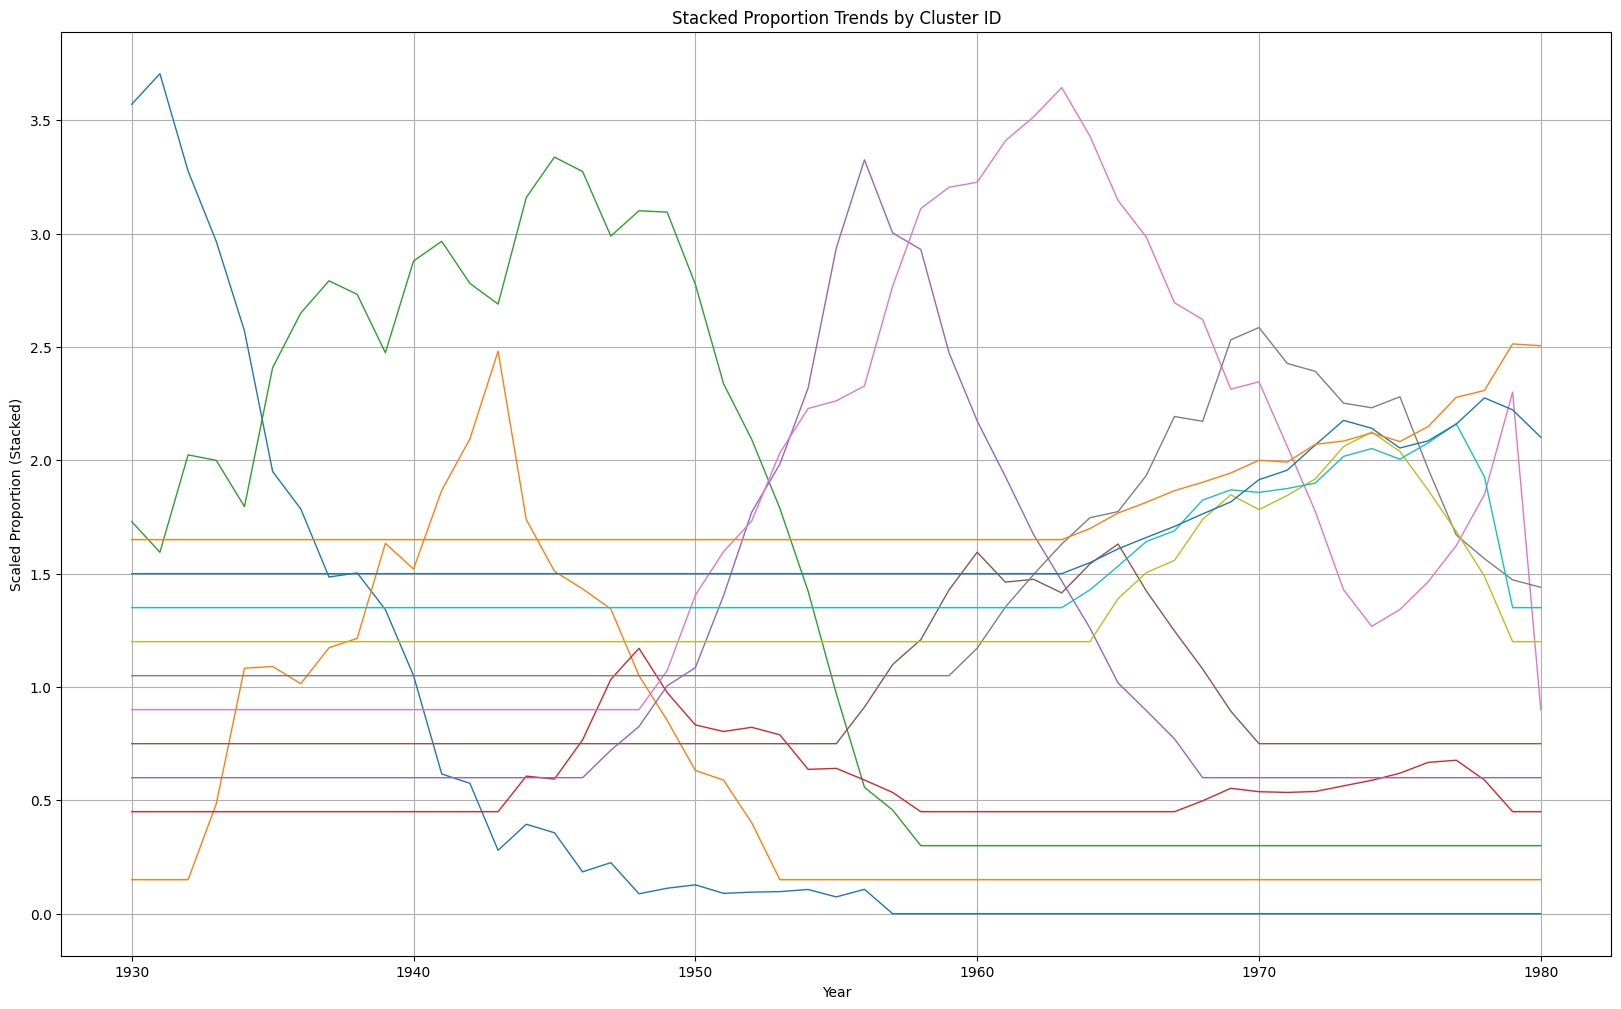

In [ ]:
import pickle
import sys
import pandas as pd
import matplotlib.pyplot as plt
import os

sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import *

# Load cluster_ave_vectors
cluster_ave_vectors = pd.read_pickle(os.path.join(cluster_path, "cluster_ave_vector.pkl"))

# Remove rows where cluster_id == -1
cluster_ave_vectors = cluster_ave_vectors[cluster_ave_vectors['cluster_id'] != -1]

# Reorder by weighted mean year
cluster_ave_vectors = reorder_clusters_by_weighted_mean_year(cluster_ave_vectors, reverse_order=False)
print("\n=== Cluster Average (Proportion) Vectors (Sorted by Weighted Mean Year) ===")

# Plot proportion trends for each cluster_id in a stacked style with different colors
year_columns = [col for col in cluster_ave_vectors.columns if col != 'cluster_id']
years = [int(year) for year in year_columns]  # Convert year strings to integers for plotting

# Set up the plot with a light background for better color visibility
plt.figure(figsize=(20, 12), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Parameters for stacking and scaling
amplitude_scale = 5  # Minimize the y-axis amplitude
vertical_spacing = 0.15  # Small vertical spacing between lines
base_level = 0  # Starting y-level for the first cluster

# Use Matplotlib's default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, row in cluster_ave_vectors.iterrows():
    cluster_id = row['cluster_id']
    proportions = row[year_columns].values
    # Scale proportions to a small range to minimize amplitude
    scaled_proportions = proportions * amplitude_scale
    # Offset each line vertically based on its position in the DataFrame
    y_values = base_level + scaled_proportions
    # Plot the line with a unique color from the color cycle
    plt.plot(years, y_values, label=f'Cluster {cluster_id}', color=colors[idx % len(colors)], linewidth=1)
    # Increment the base level for the next cluster
    base_level += vertical_spacing

# Customize the plot
plt.xlabel('Year')
plt.ylabel('Scaled Proportion (Stacked)')
plt.title('Stacked Proportion Trends by Cluster ID')
# plt.legend()
plt.grid(True)

# Save the plot
plot_path = os.path.join(cluster_path, "cluster_proportion_trends_stacked_colored.png")
plt.savefig(plot_path, bbox_inches='tight')
print(f"\n=== Stacked Colored Plot saved to {plot_path} ===")

Tech shifts for camera industry

In [9]:
# Tech shift intensity for camera industry
events = [
    # 1925,          # Leica I introduced
    1936,          # First 35mm SLR camera
    1947,          # Polaroid instant photo system
    1948,          # First 35mm SLR with pentaprism
    (1952, 1959),  # Japanese firms enter SLR market
    1959,          # Fully automatic exposure control
    1975,          # First portable digital camera
    1977,          # First mass-produced autofocus camera
    1978,          # First autofocus SLR
    1978,          # First program auto-exposure SLR
    1981,          # Mavica prototyped
    1987,          # EOS system introduced
    1988,          # First fully digital still camera
    1993,          # CMOS active-pixel sensors created
    1993,          # First digital camera with non-volatile flash memory
    1994,          # CompactFlash cards introduced
    1995,          # Consumer digital with LCD
    1995,          # First interchangeable SLR lens with image stabilization
    (1999, 2000),  # Kyocera VP-210 and Sharp J-SH04 camera phone launched
    2004,          # First mirrorless camera
    2005,          # Face-Priority AF introduced
    2008,          # First Micro Four-Thirds camera launched
    2009           # Smartphone HDR photography introduced
]

Tech shifts for robotics industry

In [ ]:
events = [
    # 1951,          # Cybernetic tortoises learn from experience
    # (1954, 1961),  # The re-programmable industrial arm arrives
    # 1959,          # Computers and machine tools converge
    # (1966, 1970),  # Shakey shows robots can reason
    # 1969,          # The Stanford all-electric arm
    # 1970,          # Robots leave Earth
    # 1972,          # First full-scale humanoid
    # (1973, 1974),  # Microprocessors hit the shop-floor
    1978,          # SCARA revolutionises electronics lines
    1979,          # Stereo-vision navigation
    1985,          # Surgical robots reach the OR
    1986,          # Reactive ‘subsumption’ control
    1995,          # ‘No Hands Across America’
    1997,          # Deep Blue beats a world champion
    1998,          # LEGO Mindstorms democratise robotics
    1999,          # AIBO brings autonomous pets to market
    2000,          # Friendly humanoid & surgical gold standard
    2001,          # Robots for danger and distance
    2002,          # Roomba turns cleaning into a robot service
    (2004, 2005),  # DARPA Grand Challenge births modern AVs
    2007,          # ROS makes robot software open and modular
    2010,          # $150 depth cameras give robots 3-D sight
    (2010, 2019),  # Safe cobots share workspaces
    2014,          # Amazon’s Kiva fleets show cloud-orchestrated swarms
    2016,          # Deep learning supercharges robot perception
    2018,          # Robots hit streets and go viral
    2021,          # Ingenuity’s powered flight on Mars
    2022,          # Foundation-model brains and humanoid bets
    (2023, 2025)   # Robots gain GPT-level reasoning and shared learning
]

Tech shifts for semiconductor chip industry

In [ ]:
events = [
    # 1951,  # Early 1950s: Germanium Transistors, specifically noted as 1951
    # 1955,  # Mid-1950s: Transition to Silicon Transistors, approximated as 1955
    # (1959, 1961),  # 1959-1961: Planar Process and Integrated Circuits
    1965,  # 1965: Integrated-Circuit Minicomputer (DEC PDP-8)
    1968,  # 1968: Introduction of Semiconductor Memory (DRAM)
    1970,  # Early 1970s: MOS Integrated Circuits, approximated as 1970
    1971,  # 1971: Microprocessor (Intel 4004)
    1975,  # Mid-1970s: CMOS Technology, approximated as 1975
    (1973, 1983),  # 1973-1983: VLSI DRAM Step-Jumps (1K to 64K)
    1985,  # Mid-1980s: Application-Specific Integrated Circuits (ASICs), approximated as 1985
    1987,  # 1987: Birth of the Pure-Play Foundry (TSMC)
    (1990, 1993),  # 1990-1993: 4M and 16M DRAM Generations
    1994,  # 1994: Semiconductor Technology Roadmap (SIA/ITRS)
    1995,  # 1995: East-Asian DRAM Ascendancy
    1995,  # Mid-1990s: Application-Specific Standard Products (ASSPs), approximated as 1995
    1999,  # Late 1990s: System-on-Chip (SoC), approximated as 1999
    2005,  # 2005: Multi-Core Processors
    2007,  # 2007: GPU Computing and GPGPU
    2011,  # 2011: 3D FinFET Transistors
    2012,  # 2012: 2.5D Chip Integration
    2012,  # 2012: ‘More-than-Moore’ and ‘Beyond-CMOS’ in ITRS
    2013,  # 2013: 3D NAND Flash Memory
    2015,  # 2015: Domain-Specific AI Accelerators (TPU)
    2015,  # 2015: RISC-V Foundation Formed
    2017,  # 2017: Chiplet-Based Modular Processors
    2018,  # 2018: 3D Logic Stacking (Foveros)
    2019,  # 2019: EUV Lithography in High-Volume Manufacturing
    2022   # 2022: Gate-All-Around (GAA) Transistors
]

Tech shifts for mobile phone industry

In [ ]:
events = []

Plot rate of mean change, median change against the year


=== Cluster Average (Proportion) Vectors (Sorted by Weighted Mean Year) ===

=== Cluster Average Vectors with Earliness ===


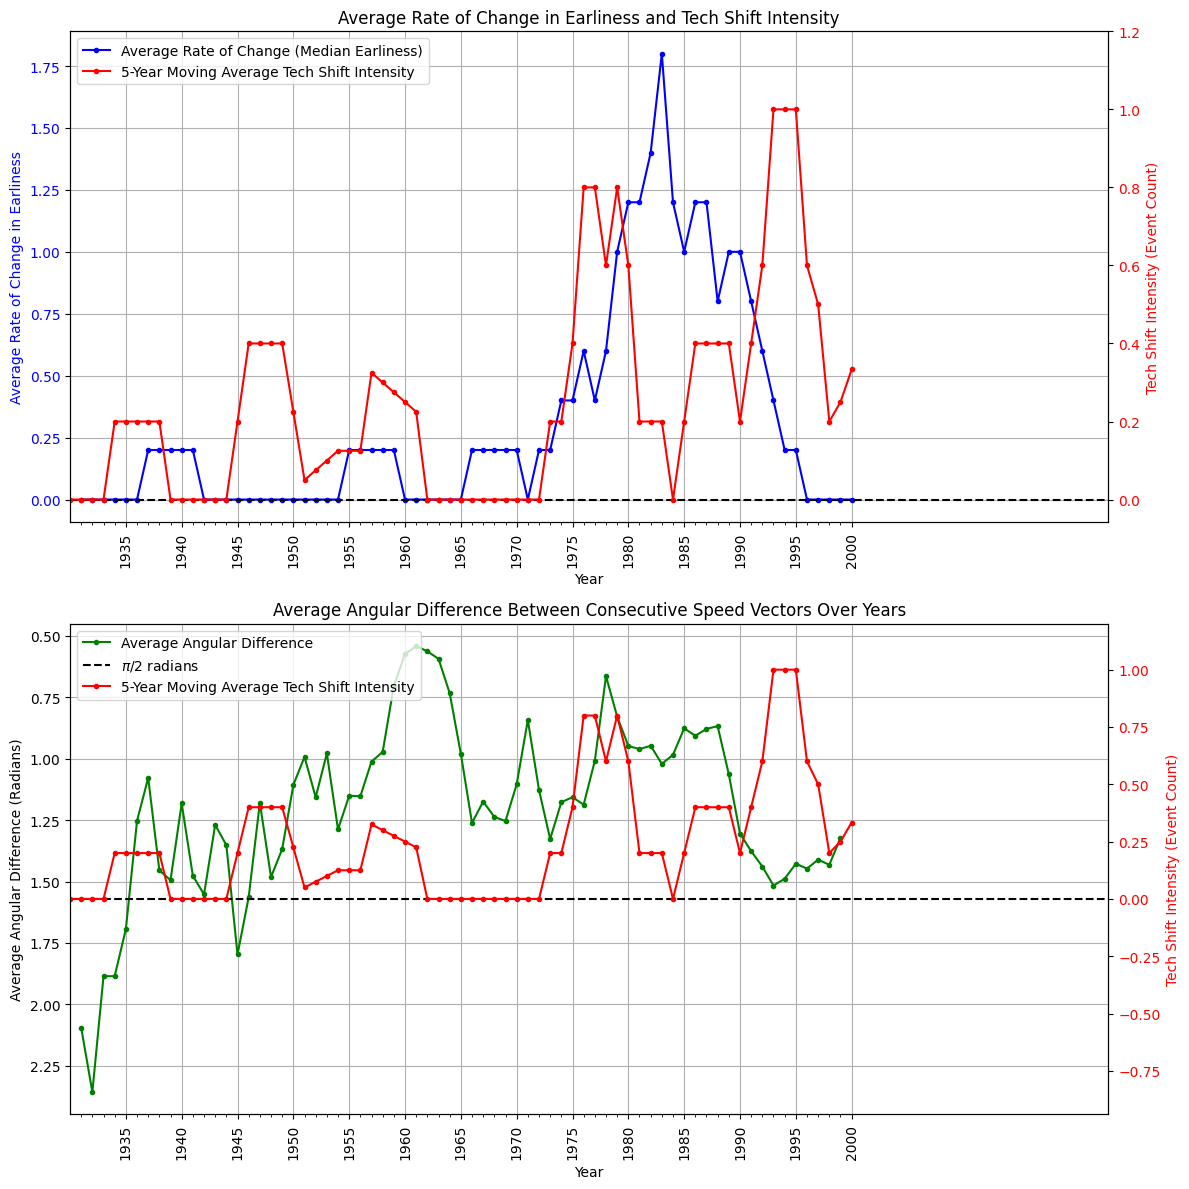


=== Combined Plot saved to /content/drive/MyDrive/TechShiftProject/camera/complete_data/predictivity_1000_20_end_2023/end_2000/cluster_number_41/rate_cluster_change_with_intensity.png ===


In [28]:
import pickle
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import *

# Load cluster_ave_vectors
cluster_ave_vectors = pd.read_pickle(os.path.join(cluster_path, "cluster_ave_vector.pkl"))

# Remove rows where cluster_id == -1
cluster_ave_vectors = cluster_ave_vectors[cluster_ave_vectors['cluster_id'] != -1]

# Reorder by weighted mean year
cluster_ave_vectors = reorder_clusters_by_weighted_mean_year(cluster_ave_vectors, reverse_order=False)
print("\n=== Cluster Average (Proportion) Vectors (Sorted by Weighted Mean Year) ===")

# Add earliness column based on row index
cluster_ave_vectors['earliness'] = cluster_ave_vectors.index
print("\n=== Cluster Average Vectors with Earliness ===")

# Extract year columns
year_columns = [col for col in cluster_ave_vectors.columns if col not in ['cluster_id', 'earliness']]
years = [int(year) for year in year_columns]

# Calculate weighted mean and median earliness for each year
mean_earliness = []
median_earliness = []

for year in year_columns:
    proportions = cluster_ave_vectors[year].values
    earliness = cluster_ave_vectors['earliness'].values
    total_weight = proportions.sum()

    # Weighted mean earliness
    if total_weight > 0:
        weighted_mean = np.sum(earliness * proportions) / total_weight
    else:
        weighted_mean = 0
    mean_earliness.append(weighted_mean)

    # Weighted median earliness (approximation via cumulative distribution)
    if total_weight > 0:
        cumsum = np.cumsum(proportions) / total_weight
        median_idx = np.where(cumsum >= 0.5)[0][0]
        weighted_median = earliness[median_idx]
    else:
        weighted_median = 0
    median_earliness.append(weighted_median)

# Compute rate of change for mean and median earliness
rate_change_mean = np.diff(mean_earliness)
rate_change_median = np.diff(median_earliness)

# Compute angular differences
def compute_angle_differences_cluster(df):
    """
    Compute the angular differences between consecutive speed vectors of cluster distributions.

    Parameters:
    df (pd.DataFrame): DataFrame with 'cluster_id', 'earliness', and year columns (e.g., '1930', '1931', ...).

    Returns:
    list: Angular differences (in degrees) between consecutive speed vectors.
    """
    year_columns = [col for col in df.columns if col not in ['cluster_id', 'earliness']]
    vectors = [df[year].values for year in year_columns]
    speed_vectors = [vectors[i+1] - vectors[i] for i in range(len(vectors)-1)]
    angular_differences = []
    for i in range(len(speed_vectors)-1):
        v1 = speed_vectors[i]
        v2 = speed_vectors[i+1]
        dot_product = np.dot(v1, v2)
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)
        if norm_v1 == 0 or norm_v2 == 0:
            angle = 0.0
        else:
            cos_angle = dot_product / (norm_v1 * norm_v2)
            cos_angle = np.clip(cos_angle, -1.0, 1.0)
            angle = np.arccos(cos_angle)
        angular_differences.append(angle)
    return angular_differences

angle_difference = compute_angle_differences_cluster(cluster_ave_vectors)

# Compute average rate along a moving window
max_window = 5
ave_rate_change_mean = flexible_moving_average(rate_change_mean, max_window)
ave_rate_change_median = flexible_moving_average(rate_change_median, max_window)
ave_angle_differences = flexible_moving_average(angle_difference, max_window)

# Initialize intensity array for years 1930 to 2025
years_intensity = np.arange(start_year, truncated_year + 1)
intensity = np.zeros(len(years_intensity))

# Process each event
for event in events:
    if isinstance(event, int):
        # Single-year event: add 1 to the corresponding year
        idx = event - start_year
        if 0 <= idx < len(intensity):
            intensity[idx] += 1
    else:
        # Year-range event: distribute 1/n across the range
        start, end = event
        n_years = end - start + 1
        weight = 1 / n_years
        for year in range(start, end + 1):
            idx = year - start_year
            if 0 <= idx < len(intensity):
                intensity[idx] += weight

# Compute 5-year moving average for intensity
ave_intensity = flexible_moving_average(intensity, max_window)

# Years for rate of change (start_year+1 to truncated_year)
plot_years = np.arange(start_year + 1, truncated_year + 1)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

# Top subplot: Plot ave_rate_change_median and tech shift intensity
ax1.plot(plot_years, ave_rate_change_median, label='Average Rate of Change (Median Earliness)', marker='.', color='blue')
ax1.axhline(y=0, color='black', linestyle='--')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Rate of Change in Earliness', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Average Rate of Change in Earliness and Tech Shift Intensity')
ax1.grid(True)

# Define major years for labeling (every 5 years)
major_years = [year for year in plot_years if year % 5 == 0]

# Set x-ticks for ax1: major ticks at every 5 years, minor ticks at every year
ax1.set_xticks(major_years)
ax1.set_xticklabels([str(year) for year in major_years], rotation=90)
ax1.set_xticks(plot_years, minor=True)
ax1.set_xlim(start_year, end_year)

# Create secondary y-axis for tech shift intensity
ax1_right = ax1.twinx()
ax1_right.plot(np.append(start_year, plot_years), ave_intensity, label='5-Year Moving Average Tech Shift Intensity', marker='.', color='red')
ax1_right.set_ylabel('Tech Shift Intensity (Event Count)', color='red')
ax1_right.tick_params(axis='y', labelcolor='red')

# Align the zero levels of ax1 and ax1_right
ylim_left = ax1.get_ylim()
zero_pos = (0 - ylim_left[0]) / (ylim_left[1] - ylim_left[0])
max_right = max(ave_intensity) * 1.2
min_right = (zero_pos * max_right) / (zero_pos - 1)
ax1_right.set_ylim(min_right, max_right)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Bottom subplot: Plot ave_angle_differences
angle_years = plot_years[:-1]  # aligns with ave_angle_differences length

ax2.plot(angle_years, ave_angle_differences,
         label='Average Angular Difference', marker='.', color='green')

pi_over_2 = np.pi / 2
ax2.axhline(y=pi_over_2, color='black', linestyle='--', label=r'$\pi/2$ radians')

ax2.set_xlabel('Year')
ax2.set_ylabel('Average Angular Difference (Radians)')  # values are radians
ax2.set_title('Average Angular Difference Between Consecutive Speed Vectors Over Years')
ax2.set_xlim(start_year, end_year)
ax2.grid(True)

# Flip y-axis upside-down
ax2.invert_yaxis()

# Set x-ticks for ax2: major ticks at every 5 years, minor ticks at every year
ax2.set_xticks(major_years)
ax2.set_xticklabels([str(year) for year in major_years], rotation=90)
ax2.set_xticks(plot_years, minor=True)

# --- Add tech shift intensity on right axis (bottom subplot) ---
ax2_right = ax2.twinx()
ax2_right.plot(years_intensity, ave_intensity,
               label='5-Year Moving Average Tech Shift Intensity',
               marker='.', color='red')
ax2_right.set_ylabel('Tech Shift Intensity (Event Count)', color='red')
ax2_right.tick_params(axis='y', labelcolor='red')

# --- Align right-axis 0 to left-axis pi/2 (after invert) ---
ylim_left = ax2.get_ylim()
ref_left = pi_over_2   # pi/2 on left axis
ref_right = 0.0        # zero on right axis

# Position of pi/2 in axes-fraction coordinates (0 bottom -> 1 top)
ref_pos = (ref_left - ylim_left[0]) / (ylim_left[1] - ylim_left[0])

# Choose an upper bound for intensity and solve for lower bound
max_right = (max(ave_intensity) * 1.2) if len(ave_intensity) > 0 else 1.0

# Solve (ref_right - min_right) / (max_right - min_right) = ref_pos  for min_right
# => min_right = (ref_right - ref_pos * max_right) / (1 - ref_pos)
if np.isclose(1 - ref_pos, 0):
    min_right = -max_right  # fallback
else:
    min_right = (ref_right - ref_pos * max_right) / (1 - ref_pos)

ax2_right.set_ylim(min_right, max_right)

# Combine legends from both axes (bottom subplot)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot
plot_path = os.path.join(cluster_path, "rate_cluster_change_with_intensity.png")
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

print(f"\n=== Combined Plot saved to {plot_path} ===")

# Get change driving meta topics with given truncated year
## First find change driving topics in each window, then cluster them

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
import ast

sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import (
    reorder_topics_by_weighted_mean_year,
    transform_avg_vector,
    insert_missing_years,
    compute_angle_differences
)

# Container to hold final merged results across all windows
all_merged_results_10pct = []  # for top 10% topics

# Main loop for processing year windows
for start in range(start_year, end_year - year_window + 2):
    end = start + year_window - 1
    print(f"\n=== Processing window: {start}-{end} ===")

    window_folder = os.path.join(dynamic_topic_path, f"{start}_{end}/")

    # Load average topic vectors
    avg_vectors = pd.read_pickle(f"{window_folder}avg_vectors.pkl")
    print("Average topic vectors loaded.")

    # 1) Normalize topic weights
    topic_columns = [col for col in avg_vectors.columns if col.startswith('topic_')]
    normalized_weights = avg_vectors[topic_columns].div(avg_vectors[topic_columns].sum(axis=1), axis=0)
    normalized_avg_vectors = avg_vectors[['year']].join(normalized_weights)
    print("Topic weights normalized.")

    # 2) Sort topics by weighted mean year
    normalized_avg_vectors_sorted = reorder_topics_by_weighted_mean_year(
        normalized_avg_vectors, reverse_order=False
    )
    print("Topics sorted by weighted mean year.")

    # 3) Convert to matrix and insert missing years
    normalized_avg_vector_matrix = transform_avg_vector(normalized_avg_vectors_sorted)
    normalized_avg_vector_matrix = insert_missing_years(
        normalized_avg_vector_matrix,
        start,  # or just start
        end     # or just end
    )
    print("Matrix transformed and missing years inserted.")


    ### EXTRA: Calculate medians for shift-driving measure


    # 4) Calculate increments year-over-year
    print("Calculating increments for each topic/year...")
    years = np.arange(start, end + 1)  # or np.arange(start+1, end+1)
    results_10pct = []

    for i in range(1, len(years)):
        current_year = years[i]
        previous_year = years[i - 1]

        current_values = normalized_avg_vector_matrix.get(current_year, pd.Series(dtype=float))
        previous_values = normalized_avg_vector_matrix.get(previous_year, pd.Series(dtype=float))

        # Compute percentage change
        with np.errstate(divide='ignore', invalid='ignore'):
            increments = ((current_values - previous_values) / previous_values) * 100
            increments.replace([np.inf, -np.inf], np.nan, inplace=True)
            increments.fillna(0, inplace=True)

        # ---------- Part A: Top 10 % with 50% cumulative cut-off ----------
        top_n_10pct = max(1, int(len(increments) * 0.10))
        # Biggest increments in descending order
        sorted_inc = increments.nlargest(top_n_10pct)
        threshold = 50          # cumulative cut-off in %
        cumulative = 0.0
        selected_topics_10pct = {}
        for topic, inc in sorted_inc.items():
            selected_topics_10pct[topic] = inc      # provisionally keep it
            cumulative += inc
            # Stop **after** adding the first topic that pushes us over the line
            if cumulative >= threshold:
                break
        # Record the selected topics
        for topic, increment in selected_topics_10pct.items():
            results_10pct.append({
                'year': current_year,
                'topic': topic,
                'increment_percentage': increment
            })


    # Create DataFrames
    results_10pct_df = pd.DataFrame(results_10pct)

    print("Increments (10%) and top 1 topic calculated.")

    # 5) Merge with topic info
    df_topic_info = pd.read_csv(f"{window_folder}topic_info.csv")
    print("Topic information loaded.")

    # Convert string lists to actual lists
    for col in ['Representation', 'KeyBERT', 'MMR', 'POS']:
        df_topic_info[col] = df_topic_info[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else []
        )

    df_topic_info['keywords'] = df_topic_info.apply(
        lambda row: list(set(row['Representation'] + row['KeyBERT'] + row['MMR'] + row['POS'])),
        axis=1
    )
    print("Keywords extracted from topic information.")

    # Merge the 10% results
    results_10pct_df['topic_num'] = results_10pct_df['topic'].str.extract(r'(\d+)').astype(int)
    merged_results_10pct = results_10pct_df.merge(
        df_topic_info[['Topic', 'keywords']],
        left_on='topic_num',
        right_on='Topic',
        how='left'
    ).drop(columns=['topic_num', 'Topic'])
    merged_results_10pct['year_window'] = f"{start}-{end}"


    # Collect final results
    all_merged_results_10pct.append(merged_results_10pct)

    print(f"Finished processing window: {start}-{end}")

# Concatenate once after processing all windows
final_merged_10pct = pd.concat(all_merged_results_10pct, ignore_index=True)

# Save them as two separate files
output_10pct_path = os.path.join(predictivity_path, "top_topic_increments_10pct_with_keywords_all.csv")

final_merged_10pct.to_csv(output_10pct_path, index=False)

print(f"\nAll windows' 10% increments results saved to: {output_10pct_path}")

Find the meta-topics within a given year range using **HDBSCAN**

In [ ]:
import os
import pandas as pd
from sklearn.metrics import pairwise_distances
import numpy as np
from sklearn.metrics import silhouette_score
from ast import literal_eval
from collections import Counter
import hdbscan  # Import HDBSCAN library

# Determine whether top10 or top1
top_level = "10pct"

# Load the dataframes
change_driving_topic_top = pd.read_csv(os.path.join(predictivity_path, f"top_topic_increments_{top_level}_with_keywords_all.csv"))
start = 1970
## Note that for the predictivity analysis,
## here 'end' is not just the last year of analysis, it also truncate the year windows that with end larger than this 'end'
# end = 2010
# end = 2000
# end = 1995
# end = 1990
end = 1980

# Extract the end year from 'year_window' and convert to integer
change_driving_topic_top['window_end_year'] = change_driving_topic_top['year_window'].str.split('-').str[1].astype(int)

# # Filter the dataframe based on 'year'
# change_driving_topic_top = change_driving_topic_top[
#     (change_driving_topic_top["year"] >= start) &
#     (change_driving_topic_top["year"] <= end)
# ]

# Filter the dataframe based on 'year' and 'window_end_year'
change_driving_topic_top = change_driving_topic_top[
    (change_driving_topic_top["year"] >= start) &
    (change_driving_topic_top["year"] <= end) &
    (change_driving_topic_top['window_end_year'] <= end)
]

# **Step 1: Convert 'keywords' from string to list**
change_driving_topic_top['keywords'] = change_driving_topic_top['keywords'].apply(lambda x: literal_eval(x))

# # **Step 2: Group by 'topic' and 'year_window' to define unique topics**
# # Aggregate keywords by combining all lists within each group
# aggregated_df = change_driving_topic_top.groupby(['topic', 'year_window']).agg({
#     'keywords': lambda x: [keyword for sublist in x for keyword in sublist],  # Flatten keyword lists
#     'year': 'first'  # Take the first year (assuming it's consistent within groups)
# }).reset_index()

# **Step 2: Alternativel, dont group
aggregated_df = change_driving_topic_top

# **Step 3: Prepare data for clustering**
# Create a vocabulary of all unique keywords from the aggregated data
all_keywords = ""  # TODO: fill in (do not commit)
vocabulary = list(set(all_keywords))

# Create a binary matrix: rows are unique topic-year pairs, columns are keywords (1 if present, 0 if not)
binary_matrix = np.array([[1 if keyword in row['keywords'] else 0 for keyword in vocabulary]
                          for _, row in aggregated_df.iterrows()])

# Compute pairwise Jaccard distances
jaccard_distances = pairwise_distances(binary_matrix, metric='jaccard')

# **Step 4: Apply HDBSCAN clustering**
# Camera
# Larger value of min_cluster_size results in fewer clusters; adjust as needed
min_cluster_size = 3    # end 1980
# min_cluster_size = 5    # end 1990
# min_cluster_size = 10    # end 2010, 2000, 1995
min_samples = 1       # Minimum samples; tune as needed
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='precomputed')
cluster_labels = hdbscan_clusterer.fit_predict(jaccard_distances)

# Add cluster labels to the aggregated dataframe (-1 indicates noise points)
aggregated_df['cluster_id'] = cluster_labels

# **Step 5: Calculate and print the number of noise points**
num_noise_points = (cluster_labels == -1).sum()
total_points = len(aggregated_df)
print(f"Number of noise points: {num_noise_points} out of {total_points} total points")

# **Step 6: Compute cluster statistics**
# Group by cluster_id to calculate metrics for each cluster
clustered_df = aggregated_df.groupby('cluster_id')

print(len(clustered_df))

# Compute statistics for each cluster
cluster_stats = clustered_df.agg(
    num_topic=('topic', 'count'),  # Number of unique topic-year pairs in the cluster
    year_range=('year', lambda x: (x.min(), x.max())),  # Earliest and latest year
    max_num_topic_by_year=('year', lambda x: x.value_counts().max())  # Max topics in any single year
).reset_index()

# Merge the statistics back into the aggregated dataframe
result_df = aggregated_df.merge(cluster_stats, on='cluster_id', how='left')

# **Step 7: Generate representative keywords and cluster names**
cluster_reps = {}  # Maps cluster_id -> {'representative_keywords': [...], 'cluster_name': str}

unique_clusters = result_df['cluster_id'].unique()
for cid in unique_clusters:
    # Get all rows for this cluster
    subset = result_df[result_df['cluster_id'] == cid]

    # Gather all keywords across these rows
    all_kws = []
    for _, r in subset.iterrows():
        all_kws.extend(r['keywords'])

    # Count keyword frequencies
    freq = Counter(all_kws)

    # Top 30 keywords
    top30 = [w for w, _ in freq.most_common(30)]

    # Top 5 keywords, joined with underscores for cluster name
    top5 = [w for w, _ in freq.most_common(5)]
    cluster_name = "_".join(top5)

    cluster_reps[cid] = {
        'representative_keywords': top30,
        'cluster_name': cluster_name
    }

# Attach the new columns to result_df
result_df['representative_keywords'] = result_df['cluster_id'].apply(
    lambda x: cluster_reps[x]['representative_keywords']
)
result_df['cluster_name'] = result_df['cluster_id'].apply(
    lambda x: cluster_reps[x]['cluster_name']
)

# Print the number of clusters (including noise as a "cluster")
n_cluster = len(result_df['cluster_id'].unique())
print(f"Number of clusters: {n_cluster}")

# **Step 8: Compute average intra-cluster Jaccard distance and silhouette score**
# Silhouette score (measures cluster cohesion vs. separation)
silhouette_avg = silhouette_score(jaccard_distances, cluster_labels, metric='precomputed')
print(f"Silhouette Score: {silhouette_avg}")

# Average intra-cluster Jaccard distance (average distance within each cluster)
intra_cluster_distances = []
for cluster in set(cluster_labels):
    if cluster != -1:  # Exclude noise points
        cluster_indices = np.where(cluster_labels == cluster)[0]
        cluster_distances = jaccard_distances[cluster_indices][:, cluster_indices]
        intra_cluster_distances.append(np.mean(cluster_distances))

avg_intra_cluster_distance = np.mean(intra_cluster_distances) if intra_cluster_distances else 0
print(f"Average Intra-Cluster Jaccard Distance: {avg_intra_cluster_distance}")

Number of noise points: 3 out of 66 total points
11
Number of clusters: 11
Silhouette Score: 0.624531579253317
Average Intra-Cluster Jaccard Distance: 0.15139063347912413


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



Save the clustered topics

In [ ]:
# **Step 9: Save the result dataframe**
output_file = os.path.join(predictivity_path, f"clustered_topics_increments_{top_level}_{start}_{end}_{n_cluster}.csv")
result_df.to_csv(output_file, index=False)
print(f"Result dataframe saved to: {output_file}")

Result dataframe saved to: /content/drive/MyDrive/TechShiftProject/camera/complete_data/predictivity_1000_20_end_2023/clustered_topics_increments_10pct_1970_1980_11.csv


## Find the patent id affiliated with the identified shift driving topics

In [ ]:
import os
import pandas as pd

# 1. Load the clustered topics
start = 1970

## Year window 20
# end = 2010
# n_cluster = 50
# end = 2000
# n_cluster = 29
# end = 1995
# n_cluster = 18
# end = 1990
# n_cluster = 25
end = 1980
n_cluster = 11

## Year window 10
# end = 2010    # without truncating
# n_cluster = 43


top_level = "10pct"

cluster_file = f"clustered_topics_increments_{top_level}_{start}_{end}_{n_cluster}.csv"
print(f"Loading clustered topics from {cluster_file}")
df_topic_clusters = pd.read_csv(os.path.join(predictivity_path, cluster_file))
print(f"  … loaded {len(df_topic_clusters):,} rows")

# 2. Keep only the shift-driving cluster rows
shift_driving_clusters = list(range(n_cluster - 1))
df_shift_clusters = df_topic_clusters[df_topic_clusters['cluster_id'].isin(shift_driving_clusters)]
print(f"Retained {len(df_shift_clusters):,} rows belonging to {len(shift_driving_clusters)} shift-driving clusters")

# 3. Read every df_id_year_topic file once and store in a dict
window_map = {}
print("Reading reference tables into memory")
for w in df_shift_clusters['year_window'].unique():
    window_key = ""  # TODO: fill in (do not commit)
    csv_path = os.path.join(dynamic_topic_path, window_key, "df_id_year_topic.csv")
    window_map[window_key] = pd.read_csv(csv_path)
    print(f"  … {window_key}: {len(window_map[window_key]):,} rows")

# 4. Collect matches
results = []
for year, df_year in df_shift_clusters.groupby('year'):
    print(f"\n===== YEAR {year} ({len(df_year)} rows) =====")
    for _, row in df_year.iterrows():
        c_id = row['cluster_id']
        topic_num = int(row['topic'].replace('topic_', ''))
        window_key = ""  # TODO: fill in (do not commit)
        df_ref = window_map[window_key]
        matches = df_ref[(df_ref['year'].isin([year-1, year, year+1])) & (df_ref['topic'] == topic_num)]
        if not matches.empty:
            print(f"  • cluster {c_id} | topic {topic_num} | window {window_key} => {len(matches)} match(es)")
            for _, m in matches.iterrows():
                results.append({'cluster_id': c_id, 'id': m['id'], 'year': m['year']})

# 5. Build and save the result table
df_results = pd.DataFrame(results)
print(f"\nCollected before de-duplication: {len(df_results):,} rows")
df_results = df_results.drop_duplicates(subset=['cluster_id', 'id'])
print(f"After de-duplication: {len(df_results):,} rows")

output_file = f"patent_shift_driving_{top_level}_{start}_{end}_{n_cluster}.csv"
df_results.to_csv(os.path.join(predictivity_path, output_file), index=False)
print(f"Saved shift-driving cluster ID-year mappings to {output_file}")

Loading clustered topics from clustered_topics_increments_10pct_1970_1980_11.csv
  … loaded 66 rows
Retained 63 rows belonging to 10 shift-driving clusters
Reading reference tables into memory
  … 1951_1970: 21,451 rows
  … 1952_1971: 23,829 rows
  … 1953_1972: 26,214 rows
  … 1954_1973: 28,378 rows
  … 1955_1974: 30,290 rows
  … 1956_1975: 32,269 rows
  … 1957_1976: 35,393 rows
  … 1958_1977: 40,360 rows
  … 1959_1978: 45,653 rows
  … 1960_1979: 52,756 rows
  … 1961_1980: 61,012 rows

===== YEAR 1970 (11 rows) =====
  • cluster 0 | topic 1 | window 1951_1970 => 1361 match(es)
  • cluster 0 | topic 1 | window 1952_1971 => 2308 match(es)
  • cluster 0 | topic 1 | window 1953_1972 => 2254 match(es)
  • cluster 0 | topic 1 | window 1954_1973 => 2222 match(es)
  • cluster 0 | topic 1 | window 1955_1974 => 2169 match(es)
  • cluster 0 | topic 1 | window 1956_1975 => 2408 match(es)
  • cluster 0 | topic 1 | window 1957_1976 => 1815 match(es)
  • cluster 0 | topic 1 | window 1958_1977 => 1849

Plot patent counts vs year

10
Number of shift driving patents (selected clusters): 28261


<ipython-input-7-14dca2ad20a5>:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


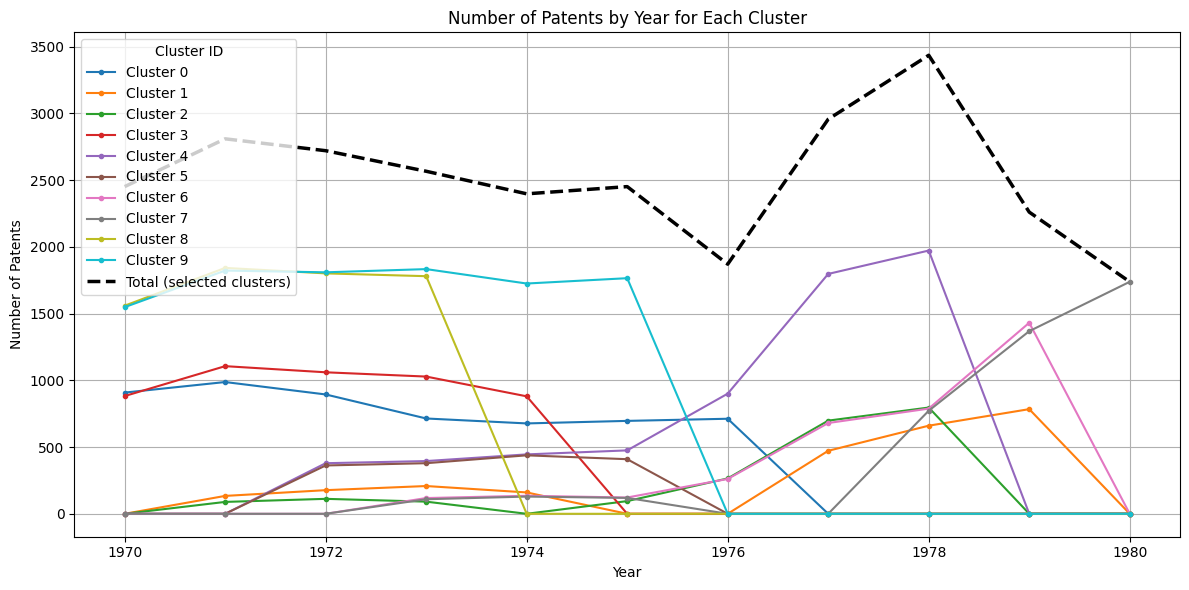

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# -----------------------------
# Hyperparameter to toggle total sum plot
plot_total = True  # Set to False to hide total line
# -----------------------------

# 1. Load the data
start = 1970
## Year window 20
# end = 2010
# n_cluster = 50
# end = 2000
# n_cluster = 29
# end = 1995
# n_cluster = 18
# end = 1990
# n_cluster = 25
end = 1980
n_cluster = 11

## Year window 10
# end = 2010    # without truncating
# n_cluster = 43

top_level = "10pct"



file_name = f"patent_shift_driving_{top_level}_{start}_{end}_{n_cluster}"
df_patent_shift_driving_cluster = pd.read_csv(
    os.path.join(predictivity_path, f"{file_name}.csv")
)

print(len(df_patent_shift_driving_cluster['cluster_id'].unique()))

# 2. Group by cluster_id and year, then count 'id'
df_counts = (
    df_patent_shift_driving_cluster
    .groupby(['cluster_id', 'year'])
    .size()
    .reset_index(name='count')
)

# 3. Plot
plt.figure(figsize=(12, 6))

# Get all unique cluster IDs
unique_clusters = sorted(df_counts['cluster_id'].unique())

# Or define the clusters of interest manually
# list_label = ["Meta-Topic (i)", "Meta-Topic (ii)", "Meta-Topic (iii)"]

num_clusters = len(unique_clusters)

# Create a colormap that can handle more than 20 colors
cmap = plt.cm.get_cmap('tab20')
colors = [cmap(i / num_clusters) for i in range(num_clusters)]

# Plot each cluster with a unique color
for idx, cluster_id in enumerate(unique_clusters):
    cluster_data = df_counts[df_counts['cluster_id'] == cluster_id]

    # --- fill missing years with zero counts
    full_years = pd.DataFrame({'year': range(start, end + 1)})
    cluster_data = (
        full_years.merge(cluster_data, on='year', how='left')
        .fillna({'cluster_id': cluster_id, 'count': 0})
        .sort_values('year')
    )

    plt.plot(
        cluster_data['year'],
        cluster_data['count'],
        marker='.',
        label=f'Cluster {cluster_id}',
        color=colors[idx]
    )

# 4. Add unique total patent count per year (if enabled)
if plot_total:
    # --- restrict total to rows whose cluster_id is in unique_clusters
    df_filtered = df_patent_shift_driving_cluster[
        df_patent_shift_driving_cluster['cluster_id'].isin(unique_clusters)
    ]
    df_unique_ids = df_filtered.drop_duplicates(subset='id')
    df_total = df_unique_ids.groupby('year').size().reset_index(name='count')

    # --- fill missing years with zero counts
    full_years = pd.DataFrame({'year': range(start, end + 1)})
    df_total = (
        full_years.merge(df_total, on='year', how='left')
        .fillna({'count': 0})
        .sort_values('year')
    )

    print(f'Number of shift driving patents (selected clusters): {len(df_unique_ids)}')
    plt.plot(
        df_total['year'],
        df_total['count'],
        color='black',
        linewidth=2.5,
        linestyle='--',
        label='Total (selected clusters)'
    )


# 5. Final plot styling
plt.title('Number of Patents by Year for Each Cluster')
plt.xlabel('Year')
plt.ylabel('Number of Patents')
plt.legend(title='Cluster ID', loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.savefig(os.path.join(predictivity_path, f"{file_name}.png"))
plt.show()

Plot cluster proportion vs year

10


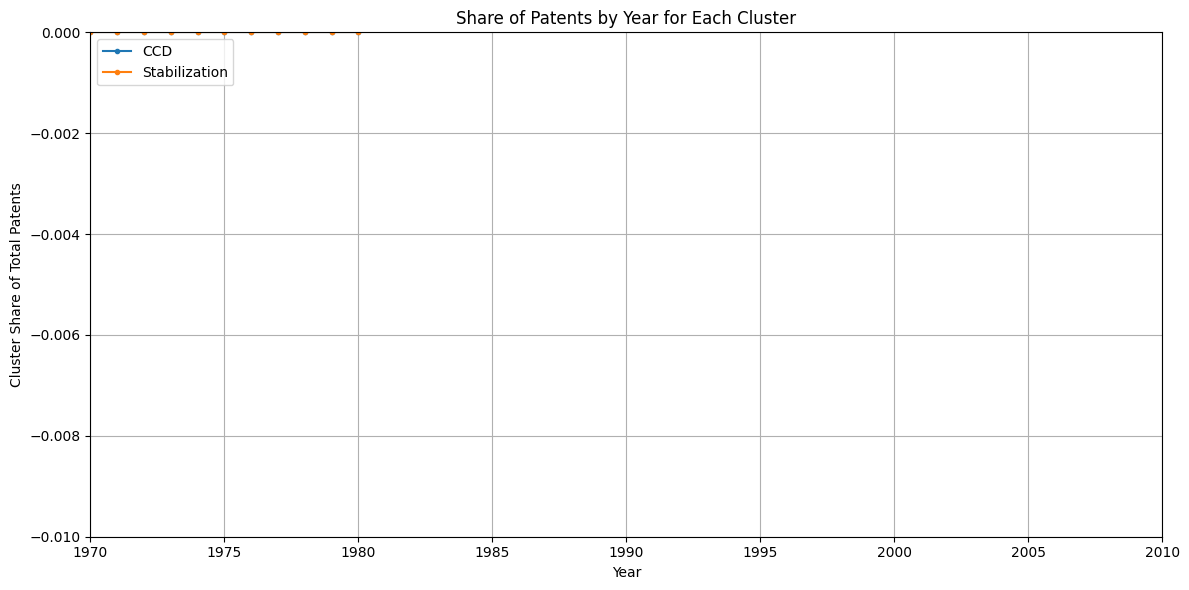

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# -----------------------------
# Hyperparameter to toggle total-patent counter printout
plot_total = True  # Set to False to skip the counter print
# -----------------------------

# 1. Load the data
start = 1970
## Year window 20
# end = 2010
# n_cluster = 50
# end = 2000
# n_cluster = 29
# end = 1995
# n_cluster = 18
# end = 1990
# n_cluster = 25
end = 1980
n_cluster = 11

## Year window 10
# end = 2010    # without truncating
# n_cluster = 43

top_level = "10pct"




file_name = f"patent_shift_driving_{top_level}_{start}_{end}_{n_cluster}"
df_patent_shift_driving_cluster = pd.read_csv(
    os.path.join(predictivity_path, f"{file_name}.csv")
)

print(len(df_patent_shift_driving_cluster['cluster_id'].unique()))

# 2. Group by cluster_id and year, then count 'id'
df_counts = (
    df_patent_shift_driving_cluster
    .groupby(['cluster_id', 'year'])
    .size()
    .reset_index(name='count')
)

# --- build the denominator: unique-patent total per year (all clusters)
df_unique_ids_total = df_patent_shift_driving_cluster.drop_duplicates(subset='id')
df_total = (
    df_unique_ids_total
    .groupby('year')
    .size()
    .reset_index(name='total')
)
full_years = pd.DataFrame({'year': range(start, end + 1)})
df_total = (
    full_years.merge(df_total, on='year', how='left')
    .fillna({'total': 0})
    .sort_values('year')
)

# 3. Plot
plt.figure(figsize=(12, 6))

# Or define the clusters of interest manually
### Year window 20
## End 2010
# cluster_ccd = [36, 42, 43]    # CCD
# cluster_stabilization = [8]    # Stablization

## End 2000
# cluster_ccd = [23, 24]    # CCD
# cluster_stabilization = [7]    # Stablization

## End 1995
# cluster_ccd = [11, 12]    # CCD

## End 1990
# cluster_ccd = [10]    # CCD

## End 1980
cluster_ccd = []    # CCD

### Year window 10
# cluster_ccd = [29, 34, 36, 41]    # CCD
# cluster_stabilization = [10]    # Stablization


# clusters = [cluster_ccd, cluster_stabilization, cluster_facial]
# list_label = ["CCD", "Stabilization", "Facial Recognition"]
# clusters = [cluster_ccd, cluster_stabilization]
# list_label = ["CCD", "Stabilization"]
clusters = [cluster_ccd]
list_label = ["CCD"]

# Plot each cluster with a unique color
y_max = 0
for idx, cluster in enumerate(clusters):
    # Plot total proportion of chosen clusters
    chosen_clusters_data = df_counts[df_counts['cluster_id'].isin(cluster)]
    total_chosen_counts = chosen_clusters_data.groupby('year')['count'].sum().reset_index(name='total_chosen_count')
    total_chosen_counts = full_years.merge(total_chosen_counts, on='year', how='left').fillna({'total_chosen_count': 0})
    total_chosen_counts = total_chosen_counts.merge(df_total, on='year', how='left')
    total_chosen_counts['total_ratio'] = np.where(
        total_chosen_counts['total'] > 0,
        total_chosen_counts['total_chosen_count'] / total_chosen_counts['total'],
        0
    )
    y_max = max(y_max, total_chosen_counts['total_ratio'].max())
    plt.plot(
        total_chosen_counts['year'],
        total_chosen_counts['total_ratio'],
        marker='.',
        label= list_label[idx]
    )

# 5. Final plot styling
plt.title('Share of Patents by Year for Each Cluster')
plt.xlabel('Year')
plt.xlim(1970, 2010)
plt.ylim(-0.01, y_max*1.2)
plt.ylabel('Cluster Share of Total Patents')
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.savefig(os.path.join(predictivity_path, f"{file_name}_ratio_all_clusters.png"))
plt.show()

# Analysis on companies' proximity on critical patents given truncated year

Parameter setting

In [ ]:
# ------------------------- Enable/Disable Metrics ------------------------- #
CALCULATE_NEAREST_NEIGHBOR = True
CALCULATE_KDE_KL          = False
CALCULATE_IFOREST         = False
CALCULATE_OCSVM           = False
CALCULATE_GAUSSIAN_KL     = False
CALCULATE_MAHALANOBIS     = True
CALCULATE_COSINE          = True

# ------------------------- Mahalanobis Regularization --------------------- #
REGULARIZE_MAHALANOBIS = True   # Set True to apply diagonal regularization
REGULARIZATION_EPSILON = 1e-5   # Small value added to diagonal

# ------------------------- Data Preparation ------------------------- #

if_before_after = 'onpoint'
# if_before_after = 'after'
# top_level = 'top1'    # top 1 each year
top_level = '10pct'    # top 10% each year

# # Load top important patents if "important"
# critical_patent_set = "important"
# top_percent = 10
# clusters = (None, "")    # Using all clusters
# shift_era = ""

# Load shift driving patents if "shift"
critical_patent_set = "shift"
year_window = 20


start = 1970
## Year window 20
end = 2010
n_cluster = 50
# end = 2000
# n_cluster = 29
# end = 1990
# n_cluster = 25
# end = 1980
# n_cluster = 11
shift_era = f"_{start}_{end}"
list_length = ''
clusters = (None, "")

# Main Steps for computing the proximity
Preparation for files

In [ ]:
import pickle

## Step 1: Get the embedding dataframe, matching ids
# Get data of all patents
if dataset not in ["sampled", "test"]:
    df_id_year = pd.read_csv(f"{folder_path}df_id_year_document.csv")
else:
    df_id_year = pd.read_csv(f"{folder_path}df_id_year_document_{constant_patent_num}_{i_sampling}.csv")

print(f"Loaded {len(df_id_year)} records")

# Filter out years outside the overall range
df_id_year = df_id_year[
    (df_id_year["year"] >= start_year) &
    (df_id_year["year"] <= end_year)
]
df_id_year.reset_index(drop=True, inplace=True)
df_id_year = df_id_year.drop(columns=['document'], errors='ignore')
print(f"Filtered {len(df_id_year)} records for year range {start_year}-{end_year}")

# Get the number of patents during the shift
df_id_year_shift = df_id_year[
    (df_id_year["year"] >= start) &
    (df_id_year["year"] <= end)
]

print(f"{len(df_id_year_shift)} records for the shift yeaer {start}-{end}")

with open(f"{embedding_path}embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)
print('Embeddings loaded')

df_id_embeddings = pd.DataFrame(embeddings)
df_id_embeddings.insert(0, 'id', df_id_year['id'])

embedding_columns = df_id_embeddings.columns.tolist()[1:]
df_id_embeddings['embedding_vector'] = df_id_embeddings[embedding_columns].values.tolist()
df_id_embeddings = df_id_embeddings[['id', 'embedding_vector']]

print(f"Embedding vectors loaded with {len(df_id_embeddings)} records")

## Step 2: Get the critical patents
# If use the top important patents, filter out the id that do not show up in the top important patents
if critical_patent_set == 'important':
    df_top_important = pd.read_csv(f'{embedding_path}top_{top_percent}_percent_importance_by_year.csv')
    print(f"Loaded {len(df_top_important)} most important patents")
    df_id_year = df_id_year[df_id_year['id'].isin(df_top_important['id'])]

# If use the shift driving patents, filter out the id that do not show up in the shift driving patents
if critical_patent_set == 'shift':
    df_shift_driving = pd.read_csv(f'{predictivity_path}patent_shift_driving_{top_level}_{start}_{end}_{n_cluster}.csv')
    if clusters[1] != "":
        df_shift_driving = df_shift_driving[df_shift_driving['cluster_id'].isin(clusters[0])]
    df_shift_driving = df_shift_driving.drop_duplicates(subset=['id'])
    print(f"Loaded {len(df_shift_driving)} most shift driving patents")
    df_id_year = df_id_year[df_id_year['id'].isin(df_shift_driving['id'])]

print(f"Proportion of shift driving patents {len(df_shift_driving)/len(df_id_year_shift)}")

# Merge the selected df_id_year with the embedding dataframe
df_id_year = df_id_year.merge(df_id_embeddings, on='id', how='left')
print(f"Merged embeddings into df_id_year, total records: {len(df_id_year)}")

# Get the first and final year of the selected critical patents
first_year = df_id_year['year'].min()
final_year = df_id_year['year'].max()

print("First year:", first_year)
print("Final year:", final_year)

Loaded 1457933 records
Filtered 1457076 records for year range 1930-2023
1025899 records for the shift yeaer 1970-2010
Embeddings loaded
Embedding vectors loaded with 1457076 records
Loaded 360256 most shift driving patents
Proportion of shift driving patents 0.3511612741605168
Merged embeddings into df_id_year, total records: 360256
First year: 1969.0
Final year: 2010.0


patent_refined_shift_driving_clusters_id_year_10pct_1970_2010_75
patent_refined_shift_driving_cluster_id_year_10pct_1970_2010_75.csv

Get company portfolio dataframe

In [ ]:
## Step 3: Get company portfolio dataframe
# The year range to for the analysis
analysis_start = 1970
analysis_end = 2010

# Load the portfolio dataframe
df_company_year_portfolio = pd.read_csv(f'{embedding_path}df_company_year_portfolio_{if_before_after}.csv')

# Filter out all rows outside analysis year range, make sure the analysis range is within the selected patent year range
df_company_year_portfolio = df_company_year_portfolio[(df_company_year_portfolio["year"] >= analysis_start) & (df_company_year_portfolio["year"] <= analysis_end)]
df_company_year_portfolio.reset_index(drop=True, inplace=True)

df_company_year_portfolio = df_company_year_portfolio.merge(df_id_embeddings, on='id', how='left')
print(f"Loaded and merged company portfolios, total records: {len(df_company_year_portfolio)}")

Loaded and merged company portfolios, total records: 4824621


## Find companies' proportion in critical patents

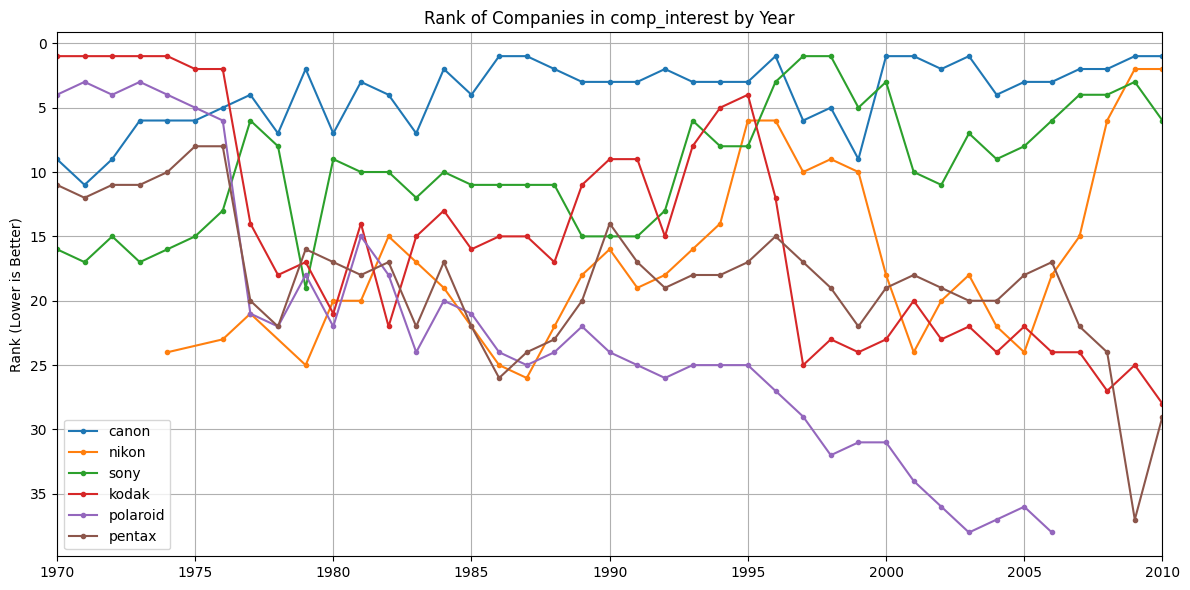

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import df_company_id_year
df_company_id_year = pd.read_csv(f"{folder_path}df_company_id_year.csv")
df_company_id_year = df_company_id_year[(df_company_id_year["year"] >= analysis_start) & (df_company_id_year["year"] <= analysis_end)]


# Define comp_interest for different tech shift
# comp_interest = ['pentax', 'canon', 'nikon', 'minolta', 'sony']    # Shift 1960-1980
comp_interest = ['canon', 'nikon', 'sony', 'kodak', 'polaroid', 'pentax', ]    # Shift 1975-2010 (shift1)
# comp_interest = ['konica', 'minolta', 'canon', 'nikon', 'sony']    # Shift 2003-2006
# comp_interest = ['canon', 'nikon', 'sony', 'fuji', 'olympus', 'panasonic', 'samsung']  # Shift 2008–2020 (shift2)


# Filter df_company_id_year to keep only IDs in df_id_year
df_filtered = df_company_id_year[df_company_id_year['id'].isin(df_id_year['id'])]

# Calculate proportions and ranks
total_ids_per_year = df_filtered.groupby('year').size().reset_index(name='total_ids')
company_ids_per_year = df_filtered.groupby(['year', 'company']).size().reset_index(name='company_ids')
merged = company_ids_per_year.merge(total_ids_per_year, on='year')
merged['proportion'] = merged['company_ids'] / merged['total_ids']
merged['rank'] = merged.groupby('year')['proportion'].rank(method='dense', ascending=False).astype(int)
df_proportions = merged[['company', 'year', 'proportion', 'rank']]

# Find companies ranked 1st at least n times
n = 3  # Minimum number of times ranked 1st
top_1 = df_proportions[df_proportions['rank'] == 1][['company', 'year']].groupby('company').size().reset_index(name='top_1_count')
comp_top_1 = top_1[top_1['top_1_count'] >= n]['company'].tolist()

# Plot ranks
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))


# Plot rank for comp_interest
for company in comp_interest:
    company_data = df_proportions[df_proportions['company'] == company]
    if not company_data.empty:
        ax1.plot(company_data['year'].tolist(), company_data['rank'].tolist(), marker='.', label=company)
ax1.set_title('Rank of Companies in comp_interest by Year')
ax1.set_ylabel('Rank (Lower is Better)')
ax1.invert_yaxis()
ax1.legend()
ax1.grid(True)

# # Plot proportion for comp_interest
# for company in comp_interest:
#     company_data = df_proportions[df_proportions['company'] == company]
#     if not company_data.empty:
#         ax2.plot(company_data['year'].tolist(), company_data['proportion'].tolist(), marker='.', label=company)
# ax2.set_title('Proportion of Companies in comp_interest by Year')
# ax2.set_ylabel('Proportion')
# ax2.legend()
# ax2.grid(True)


plt.xlim(1970, 2010)
plt.tight_layout()
plt.savefig(f'{predictivity_path}company_ranks_dominance_plot{critical_patent_set}_shift1_end_{end}.png')
# plt.savefig(f'{predictivity_path}company_ranks_dominance_plot{critical_patent_set}_shift2_ed_{end}.png')
plt.show()

Main Calculation

In [ ]:
!pip install hnswlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp311-cp311-linux_x86_64.whl size=2382529 sha256=99c47dfe53f0d59638d1b9dff94e4aaf36894cda9d8f6a5b620a78e324c00adf
  Stored in directory: /root/.cache/pip/wheels/ea/4e/27/39aebca9958719776e36fada290845a7ef10f053ad70e22ceb
Successfully built hnswlib


In [ ]:
import numpy as np
import time
from scipy.spatial.distance import cosine
from numpy.linalg import inv, LinAlgError
import pickle

# For anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# For KDE-based KL
from sklearn.neighbors import KernelDensity

# Import HNSWlib for approximate nearest neighbors
import hnswlib



# # ------------------------- Remove Specific Zero-Variance Dimensions ------------------------- #
# print("Step 4: Removing specific zero-variance dimensions")

# dims_to_remove = [127, 223, 319]

# def remove_dims(vec, dims):
#     if isinstance(vec, np.ndarray):
#         vec = vec.tolist()
#     return [v for i, v in enumerate(vec) if i not in dims]

# df_id_year['embedding_vector'] = df_id_year['embedding_vector'].apply(
#     lambda x: remove_dims(x, dims_to_remove) if x is not None else x
# )


# df_company_year_portfolio['embedding_vector'] = df_company_year_portfolio['embedding_vector'].apply(
#     lambda x: remove_dims(x, dims_to_remove) if x is not None else x
# )

# print(f"Removed dimensions {dims_to_remove} from all embedding vectors")

# ------------------------- Helper Functions ------------------------- #
def kl_divergence_gaussian(mean_p, cov_p, mean_q, cov_q):
    """Compute KL divergence between two multivariate Gaussians: KL(P || Q)."""
    if mean_p is None or cov_p is None or mean_q is None or cov_q is None:
        return np.nan
    dim = mean_p.shape[0]
    try:
        cov_q_inv = inv(cov_q)
    except LinAlgError:
        return np.nan
    trace_term = np.trace(cov_q_inv @ cov_p)
    mean_diff = mean_q - mean_p
    quad_term = mean_diff.T @ cov_q_inv @ mean_diff
    log_det_p = np.linalg.slogdet(cov_p)[1]  # log(det(cov_p))
    log_det_q = np.linalg.slogdet(cov_q)[1]  # log(det(cov_q))
    log_det_ratio = log_det_q - log_det_p
    return 0.5 * (trace_term + quad_term - dim + log_det_ratio)

def kl_divergence_kde(p_samples, q_samples, bandwidth=0.5):
    """Compute KL divergence KL(P||Q) using Kernel Density Estimation."""
    if len(p_samples) < 2 or len(q_samples) < 2:
        return np.nan
    kde_p = KernelDensity(bandwidth=bandwidth).fit(p_samples)
    kde_q = KernelDensity(bandwidth=bandwidth).fit(q_samples)
    log_p = kde_p.score_samples(p_samples)  # log density of P at points in P
    log_q = kde_q.score_samples(p_samples)  # log density of Q at points in P
    return np.mean(log_p - log_q)

# ------------------------- Distance + Anomaly Calculations ------------------------- #
print("Step 5: Starting Distance Calculations")

df_id_year['embedding_vector'] = df_id_year['embedding_vector'].apply(lambda x: np.array(x))
df_company_year_portfolio['embedding_vector'] = df_company_year_portfolio['embedding_vector'].apply(lambda x: np.array(x))

all_years = sorted(df_company_year_portfolio['year'].unique())
print(f"Calculating measures for {len(all_years)} years, but only the first year to test time-cost")

cosine_results      = []
mahalanobis_results = []
nn_results          = []
iforest_results     = []
ocsvm_results       = []
kl_results          = []
kde_kl_results      = []

for yr in all_years:
    print(f"\nProcessing Year: {yr}")

    df_docs_yr = df_id_year[df_id_year['year'] == yr]
    if len(df_docs_yr) == 0:
        print(f"  No documents for year {yr}, skipping.")
        continue

    doc_vectors_yr = np.stack(df_docs_yr['embedding_vector'].values)
    doc_center_of_mass = doc_vectors_yr.mean(axis=0)

    # For Gaussian KL
    if len(doc_vectors_yr) > 1:
        doc_cov = np.cov(doc_vectors_yr, rowvar=False)
    else:
        doc_cov = None

    df_companies_yr = df_company_year_portfolio[df_company_year_portfolio['year'] == yr]
    if len(df_companies_yr) == 0:
        print(f"  No companies for year {yr}, skipping.")
        continue

    companies_yr = df_companies_yr['company'].unique()
    print(f"  Found {len(companies_yr)} companies for year {yr}")

    for comp in companies_yr:
        df_comp_yr = df_companies_yr[df_companies_yr['company'] == comp]
        if len(df_comp_yr) == 0:
            continue

        comp_vectors = np.stack(df_comp_yr['embedding_vector'].values)
        comp_center_of_mass = comp_vectors.mean(axis=0)

        # (1) Cosine
        if CALCULATE_COSINE:
            start_t = time.time()
            cos_dist = cosine(doc_center_of_mass, comp_center_of_mass)
            cos_time = time.time() - start_t
            print(f"    {comp} - Cosine Distance = {cos_dist:.6f}, time = {cos_time:.4f}s")

            cosine_results.append({
                'year': yr,
                'company': comp,
                'ave_cosine_distance': cos_dist,
                'time_cosine': cos_time
            })

        # (2) Mahalanobis
        if CALCULATE_MAHALANOBIS:
            start_t = time.time()
            if len(comp_vectors) <= 1:
                avg_md = np.nan
                print(f"    {comp} - Not enough vectors for Mahalanobis distance")
            else:
                cov_comp = np.cov(comp_vectors, rowvar=False)

                # ----- New: Regularize or Shrink Covariance if chosen ----- #
                if REGULARIZE_MAHALANOBIS:
                    # Diagonal Regularization
                    eps_mat = np.eye(cov_comp.shape[0]) * REGULARIZATION_EPSILON
                    cov_comp = cov_comp + eps_mat

                try:
                    cov_inv = inv(cov_comp)
                    dist_list = []
                    for x in doc_vectors_yr:
                        diff = x - comp_center_of_mass
                        md_sq = diff @ cov_inv @ diff.T
                        dist_list.append(np.sqrt(md_sq))
                    avg_md = np.mean(dist_list)
                    print(f"    {comp} - Mahalanobis Distance = {avg_md:.6f}")
                except LinAlgError:
                    avg_md = np.nan
                    print(f"    {comp} - Singular covariance matrix, skipping Mahalanobis")
            mahala_time = time.time() - start_t
            print(f"      Mahalanobis time = {mahala_time:.4f}s")

            mahalanobis_results.append({
                'year': yr,
                'company': comp,
                'ave_mahalanobis_distance': avg_md,
                'time_mahalanobis': mahala_time
            })

        # (3) Nearest Neighbor using HNSWlib
        if CALCULATE_NEAREST_NEIGHBOR:
            start_t = time.time()
            if len(comp_vectors) < 1:
                avg_nn_dist = np.nan
                print(f"    {comp} - No vectors for nearest-neighbor distance")
            else:
                k = min(3, len(comp_vectors))

                # Build a small HNSW index for comp_vectors
                dim = comp_vectors.shape[1]
                p = hnswlib.Index(space='cosine', dim=dim)
                p.init_index(max_elements=len(comp_vectors), ef_construction=200, M=16)
                p.add_items(comp_vectors)

                # Tune ef for better accuracy/speed trade-off
                p.set_ef(50)

                nn_distances_for_all_docs = []
                for doc in doc_vectors_yr:
                    # Query top-k neighbors
                    labels, distances = p.knn_query(doc, k=k)
                    # distances is a 2D array: distances[0] are the distances for this single query
                    nn_mean = distances[0].mean()
                    nn_distances_for_all_docs.append(nn_mean)

                avg_nn_dist = np.mean(nn_distances_for_all_docs)
                print(f"    {comp} - Approx. Nearest Neighbor Distance = {avg_nn_dist:.6f}")

            nn_time = time.time() - start_t
            print(f"      Nearest Neighbor time = {nn_time:.4f}s")

            nn_results.append({
                'year': yr,
                'company': comp,
                'ave_nearest_neighbor_distance': avg_nn_dist,
                'time_nearest_neighbor': nn_time
            })

        # (4) Isolation Forest
        if CALCULATE_IFOREST:
            start_t = time.time()
            if len(comp_vectors) < 2:
                avg_iforest = np.nan
                print(f"    {comp} - Not enough vectors for Isolation Forest")
            else:
                iso_forest = IsolationForest(
                    n_estimators=100,
                    contamination='auto',
                    random_state=42
                )
                iso_forest.fit(comp_vectors)
                iso_scores = iso_forest.decision_function(doc_vectors_yr)
                avg_iforest = np.mean(iso_scores)
                print(f"    {comp} - IF Score = {avg_iforest:.6f}")
            iforest_time = time.time() - start_t
            print(f"      Isolation Forest time = {iforest_time:.4f}s")

            iforest_results.append({
                'year': yr,
                'company': comp,
                'avg_iforest_score': avg_iforest,
                'time_iforest': iforest_time
            })

        # (5) One-Class SVM
        if CALCULATE_OCSVM:
            start_t = time.time()
            if len(comp_vectors) < 2:
                avg_ocsvm = np.nan
                print(f"    {comp} - Not enough vectors for One-Class SVM")
            else:
                oc_svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
                oc_svm.fit(comp_vectors)
                oc_scores = oc_svm.decision_function(doc_vectors_yr)
                avg_ocsvm = np.mean(oc_scores)
                print(f"    {comp} - OC-SVM Score = {avg_ocsvm:.6f}")
            ocsvm_time = time.time() - start_t
            print(f"      One-Class SVM time = {ocsvm_time:.4f}s")

            ocsvm_results.append({
                'year': yr,
                'company': comp,
                'avg_ocsvm_score': avg_ocsvm,
                'time_ocsvm': ocsvm_time
            })

        # (6) Gaussian KL-Divergence
        if CALCULATE_GAUSSIAN_KL:
            start_t = time.time()
            if doc_cov is None or len(comp_vectors) < 2:
                kl_val = np.nan
                print(f"    {comp} - Not enough vectors for Gaussian KL-Divergence")
            else:
                comp_cov = np.cov(comp_vectors, rowvar=False)
                kl_val = kl_divergence_gaussian(doc_center_of_mass, doc_cov, comp_center_of_mass, comp_cov)
                print(f"    {comp} - KL-Divergence (Gauss) = {kl_val:.6f}")
            kl_time = time.time() - start_t
            print(f"      Gaussian KL time = {kl_time:.4f}s")

            kl_results.append({
                'year': yr,
                'company': comp,
                'gaussian_kl_divergence': kl_val,
                'time_kl': kl_time
            })

        # (7) KDE KL-Divergence
        if CALCULATE_KDE_KL:
            start_t = time.time()
            kl_val_kde = kl_divergence_kde(doc_vectors_yr, comp_vectors, bandwidth=0.5)
            print(f"    {comp} - KL-Divergence (KDE) = {kl_val_kde:.6f}")
            kl_kde_time = time.time() - start_t
            print(f"      KDE KL time = {kl_kde_time:.4f}s")

            kde_kl_results.append({
                'year': yr,
                'company': comp,
                'kde_kl_divergence': kl_val_kde,
                'time_kde_kl': kl_kde_time
            })

# ------------------------- Save Results to CSV ------------------------- #
print("\nStep 7: Saving Results to CSV")

if CALCULATE_COSINE:
    df_cosine_results = pd.DataFrame(cosine_results)
    cos_csv = f"{comprehensive_path}cosine_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_cosine_results.to_csv(cos_csv, index=False)
    print(f"Cosine distances saved to: {cos_csv}")

if CALCULATE_MAHALANOBIS:
    df_mahalanobis_results = pd.DataFrame(mahalanobis_results)
    maha_csv = f"{comprehensive_path}mahalanobis_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_mahalanobis_results.to_csv(maha_csv, index=False)
    print(f"Mahalanobis distances saved to: {maha_csv}")

if CALCULATE_NEAREST_NEIGHBOR:
    df_nn_results = pd.DataFrame(nn_results)
    nn_csv = f"{comprehensive_path}nearest_neighbor_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_nn_results.to_csv(nn_csv, index=False)
    print(f"Nearest neighbor distances saved to: {nn_csv}")

if CALCULATE_IFOREST:
    df_iforest_results = pd.DataFrame(iforest_results)
    iforest_csv = f"{comprehensive_path}iforest_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_iforest_results.to_csv(iforest_csv, index=False)
    print(f"Isolation Forest scores saved to: {iforest_csv}")

if CALCULATE_OCSVM:
    df_ocsvm_results = pd.DataFrame(ocsvm_results)
    ocsvm_csv = f"{comprehensive_path}ocsvm_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_ocsvm_results.to_csv(ocsvm_csv, index=False)
    print(f"One-Class SVM scores saved to: {ocsvm_csv}")

if CALCULATE_GAUSSIAN_KL:
    df_kl_results = pd.DataFrame(kl_results)
    kl_csv = f"{comprehensive_path}kl_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_kl_results.to_csv(kl_csv, index=False)
    print(f"Gaussian KL-Divergence saved to: {kl_csv}")

if CALCULATE_KDE_KL:
    df_kde_kl_results = pd.DataFrame(kde_kl_results)
    kde_kl_csv = f"{comprehensive_path}kde_kl_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_kde_kl_results.to_csv(kde_kl_csv, index=False)
    print(f"KDE KL-Divergence saved to: {kde_kl_csv}")

print("\n Script completed successfully.")

Streaming output truncated to the last 5000 lines.
    leica - Approx. Nearest Neighbor Distance = 0.559811
      Nearest Neighbor time = 0.2754s
    lenovo - Cosine Distance = 0.425372, time = 0.0000s
    lenovo - Mahalanobis Distance = 324.784010
      Mahalanobis time = 0.3911s
    lenovo - Approx. Nearest Neighbor Distance = 0.733642
      Nearest Neighbor time = 0.1316s
    lg - Cosine Distance = 0.206638, time = 0.0000s
    lg - Mahalanobis Distance = 273.070119
      Mahalanobis time = 0.3995s
    lg - Approx. Nearest Neighbor Distance = 0.596745
      Nearest Neighbor time = 0.1544s
    logitech - Cosine Distance = 0.398461, time = 0.0001s
    logitech - Mahalanobis Distance = 320.772649
      Mahalanobis time = 0.3887s
    logitech - Approx. Nearest Neighbor Distance = 0.728230
      Nearest Neighbor time = 0.1359s
    microsoft - Cosine Distance = 0.410003, time = 0.0000s
    microsoft - Mahalanobis Distance = 299.438674
      Mahalanobis time = 0.4107s
    microsoft - Approx

Plot company trends by proximity measures and their ranks

Companies that have rank 1 at least 1 times: ['agfa', 'canon', 'fuji', 'hitachi', 'kodak', 'mitsubishi', 'olympus', 'panasonic', 'ricoh', 'sharp', 'toshiba']


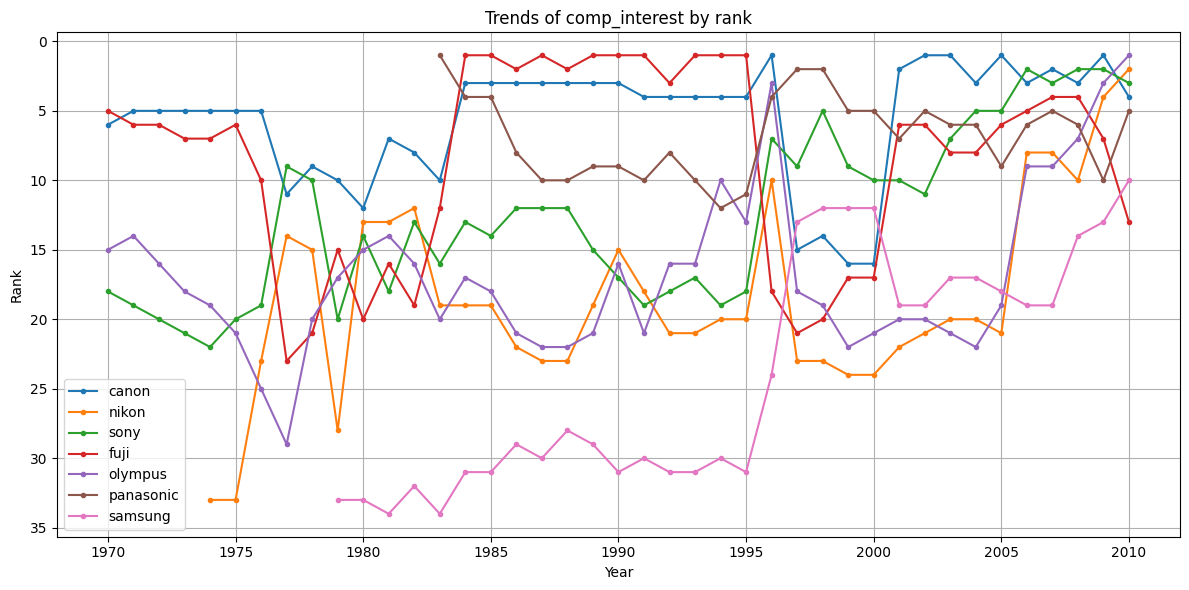

In [ ]:
import matplotlib.pyplot as plt

# --- User-provided variables ---

if_before_after = 'onpoint'
# if_before_after = 'after'

measure = "cosine_distance"
measure_column = "ave_cosine_distance"
# measure = "mahalanobis_distance"
# measure_column = "ave_mahalanobis_distance"
# measure = "nearest_neighbor_distance"
# measure_column = "ave_nearest_neighbor_distance"

# Define comp_interest for different tech shift
# comp_interest = ['pentax', 'canon', 'nikon', 'minolta', 'sony']    # Shift 1960-1980
# comp_interest = ['canon', 'nikon', 'sony', 'kodak', 'polaroid', 'pentax', ]    # Shift 1975-2010
# comp_interest = ['konica', 'minolta', 'canon', 'nikon', 'sony']    # Shift 2003-2006
comp_interest = ['canon', 'nikon', 'sony', 'fuji', 'olympus', 'panasonic', 'samsung']  # Shift 2008–2020

## Clusters from shift 1970-2010
clusters = (None, "")

## Clusters from shift 1975-2010
# clusters = (short_list, "_core")
# clusters = (long_list, "_extended")

## Clusters from shift 1975-1985
# clusters = ([1, 3], "_semicoductor")    # Semiconductor Processes
# clusters = ([8, 23, 26], "_sensor")    # Imaging Sensors
# clusters = ([2, 5, 11, 22], "_imaging")    # Imaging Devices / Processing
# clusters = ([7], "_focus")    # Autofocus

## Clusters from shift 1995-2010
# clusters = ([1, 9], "_algorithm")    # Algorithm (Stabilization, Compression)
# clusters = ([2, 31, 37], "_mobile")    # Mobile Phone, Portability, Module Manufacturing
# clusters = ([10, 22], "_display")    # Display / LCD
# clusters = ([32], "_cmos")    # CMOS
# clusters = ([21], "_furtherdigital")    # Further Digitalization

top_record = 1    # number of times ranked at the top

# --- Load Data ---
df_year_company_measure = pd.read_csv(
    f"{comprehensive_path}{measure}_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
)

# --- Step 1: Rank companies (by year) according to their measure_column ---
if measure == 'ocsvm_distance':
    df_year_company_measure['rank'] = df_year_company_measure.groupby('year')[measure_column].rank(method='dense', ascending=False)
else:
    df_year_company_measure['rank'] = df_year_company_measure.groupby('year')[measure_column].rank(method='dense', ascending=True)

# --- Step 2: Find companies that have rank 1 at least top_record times across all years ---
df_top_1 = df_year_company_measure[df_year_company_measure['rank'] == 1]
count_top_1 = df_top_1.groupby('company').size()
comp_top_1 = count_top_1[count_top_1 >= top_record].index.tolist()

print(f"Companies that have rank 1 at least {top_record} times:", comp_top_1)

# --- Prepare DataFrames for plotting ---
df_interest = df_year_company_measure[df_year_company_measure['company'].isin(comp_interest)]
df_top1_filtered = df_year_company_measure[df_year_company_measure['company'].isin(comp_top_1)]

# --- Step 3: Generate subplots (1 column x 4 rows) ---
# fig, axes = plt.subplots(4, 1, figsize=(12, 32), sharex=False)
# fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=False)

# 2. Trends of comp_interest by rank
ax.set_title("Trends of comp_interest by rank")
for company in comp_interest:
    sub_df = df_interest[df_interest['company'] == company]
    ax.plot(sub_df['year'], sub_df['rank'], marker='.', label=company)
ax.invert_yaxis()
ax.set_xlabel("Year")
ax.set_ylabel("Rank")
ax.legend()
ax.grid(True)
# ax.set_xlim(1970, 2000)
# ax.set_xlim(1995, 2010)


# # 1. Trends of comp_interest by measure_column
# axes[0].set_title("Trends of comp_interest by measure_column")
# for company in comp_interest:
#     sub_df = df_interest[df_interest['company'] == company]
#     axes[0].plot(sub_df['year'], sub_df[measure_column], marker='.', label=company)
# axes[0].set_xlabel("Year")
# axes[0].set_ylabel(measure_column)
# axes[0].legend()
# axes[0].grid(True)

# # 2. Trends of comp_interest by rank
# axes[1].set_title("Trends of comp_interest by rank")
# for company in comp_interest:
#     sub_df = df_interest[df_interest['company'] == company]
#     axes[1].plot(sub_df['year'], sub_df['rank'], marker='.', label=company)
# axes[1].invert_yaxis()
# axes[1].set_xlabel("Year")
# axes[1].set_ylabel("Rank")
# axes[1].legend()
# axes[1].grid(True)

# # 3. Trends of comp_top_1 by measure_column
# axes[2].set_title("Trends of comp_top_1 by measure_column")
# for company in comp_top_1:
#     sub_df = df_top1_filtered[df_top1_filtered['company'] == company]
#     axes[2].plot(sub_df['year'], sub_df[measure_column], marker='.', markersize=2, label=company)
# axes[2].set_xlabel("Year")
# axes[2].set_ylabel(measure_column)
# axes[2].legend()
# axes[2].grid(True)

# # 4. Trends of comp_top_1 by rank
# axes[3].set_title("Trends of comp_top_1 by rank")
# for company in comp_top_1:
#     sub_df = df_top1_filtered[df_top1_filtered['company'] == company]
#     axes[3].plot(sub_df['year'], sub_df['rank'], marker='.', markersize=2, label=company)
# axes[3].invert_yaxis()
# axes[3].set_xlabel("Year")
# axes[3].set_ylabel("Rank")
# axes[3].legend()
# axes[3].grid(True)

plt.tight_layout()

# --- Step 4: Save the figure ---
# plt.savefig(f"{comprehensive_path}trends_{measure}_by_year_company_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}_shift1.png", dpi=300)
plt.savefig(f"{comprehensive_path}trends_{measure}_by_year_company_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}_shift2.png", dpi=300)
plt.show()